# T6 — Pressure Analysis & Cadence Extraction

Loads and processes raw sensor data for all 23 participants in the final study. Extracts step cadence from the pressure insole time series, computes per-session statistics, and exports the results tables used by all other notebooks.

**Run this notebook first** — all other T6 notebooks depend on its exports.

## Contents
- **Data loading** — parse pressure CSVs for each participant
- **Cadence extraction** — adaptive step detection, rolling SPM calculation
- **Tempo condition analysis** — baseline vs manipulation cadence, group trajectories
- **Weight condition analysis** — gait quality metrics, contact/swing analysis
- **Exports** — CSV tables and figures to `exports/`

In [1259]:
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
from scipy.signal import find_peaks
from scipy import stats

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120, "font.size": 14})
DATA_DIR = Path(".")

In [1260]:
def parse_pressure_file(path):
    """Parse any semicolon-delimited pressure CSV into time_s, L_toe, L_heel, R_toe, R_heel."""
    path = Path(path)
    if not path.exists():
        return pd.DataFrame()
    raw = path.read_bytes()
    data = raw.replace(b"\r\n", b"\n").replace(b"\r", b"\n").decode("utf-8", errors="replace")
    records = [r.strip() for r in data.split(";") if r.strip()]
    rows = []
    for rec in records:
        rec = re.sub(r"^\d+,\s*", "", rec)   # strip leading index field
        nums = re.findall(r"[\d]+\.?[\d]*", rec)
        if len(nums) < 5:
            continue
        try:
            ts = float(nums[0])
            sensors = [float(n) for n in nums[1:] if float(n) <= 1023]
            if len(sensors) < 4:
                continue
            rows.append({"ts_ms": ts, "L_toe": sensors[0], "L_heel": sensors[1],
                         "R_toe": sensors[2], "R_heel": sensors[3]})
        except ValueError:
            continue
    if not rows:
        return pd.DataFrame()
    df = pd.DataFrame(rows)
    df["time_s"] = (df["ts_ms"] - df["ts_ms"].iloc[0]) / 1000.0
    return df


def parse_imu_pressure_file(path):
    """Parse IMU-derived pressure_from_imu.csv (device_ms,toe_L,heel_L,toe_R,heel_R)."""
    path = Path(path)
    if not path.exists():
        return pd.DataFrame()
    df = pd.read_csv(path)
    df = df.rename(columns={"toe_L": "L_toe", "heel_L": "L_heel",
                             "toe_R": "R_toe", "heel_R": "R_heel"})
    for col in ["L_toe", "L_heel", "R_toe", "R_heel"]:
        if col not in df.columns:
            df[col] = float("nan")
    df = df.dropna(subset=["device_ms"]).reset_index(drop=True)
    df["time_s"] = (df["device_ms"] - df["device_ms"].iloc[0]) / 1000.0
    return df

In [1261]:
def parse_tempo_spm(path):
    """Extract time_s, device SPM (second-to-last), and scale factor (last) from a tempo CSV."""
    path = Path(path)
    if not path.exists():
        return pd.DataFrame()
    raw = path.read_bytes()
    data = raw.replace(b"\r\n", b"\n").replace(b"\r", b"\n").decode("utf-8", errors="replace")
    records = [r.strip() for r in data.split(";") if r.strip()]
    rows = []
    for rec in records:
        rec = re.sub(r"^\d+,\s*", "", rec)
        nums = re.findall(r"[\d]+\.?[\d]*", rec)
        if len(nums) < 3:
            continue
        try:
            rows.append({"ts_ms": float(nums[0]), "spm": float(nums[-2]), "scale": float(nums[-1])})
        except ValueError:
            continue
    if not rows:
        return pd.DataFrame()
    df = pd.DataFrame(rows)
    df["time_s"] = (df["ts_ms"] - df["ts_ms"].iloc[0]) / 1000.0
    return df

In [1262]:
def detect_steps_adaptive(time_s, signal,
                           lo_window_ms=400, hi_window_ms=3000,
                           on_ratio=0.70, off_ratio=0.35,
                           min_range=80, debounce_ms=300):
    """
    Python port of calculatingbounds.js adaptive threshold step detector.
    Tracks rolling min (baseline) and rolling max (peak) to build an adaptive
    ON/OFF threshold, with hysteresis and debounce — matching the Max patch logic.
    Returns an array of trigger sample indices.
    """
    signal = np.asarray(signal, dtype=float)
    n = len(signal)
    if n == 0:
        return np.array([], dtype=int)

    dt_ms = float(np.median(np.diff(time_s)) * 1000) if n > 1 else 5.0
    lo_win   = max(8,  int(round(lo_window_ms / dt_ms)))
    hi_win   = max(20, int(round(hi_window_ms / dt_ms)))
    debounce = max(1,  int(round(debounce_ms  / dt_ms)))

    triggers  = []
    is_active = False
    since_last = 999

    for i in range(n):
        since_last += 1
        val      = signal[i]
        lo_slice = signal[max(0, i + 1 - lo_win) : i + 1]
        hi_slice = signal[max(0, i + 1 - hi_win) : i + 1]
        lo = lo_slice.min()
        hi = hi_slice.max()
        rng = hi - lo

        if rng > min_range and len(lo_slice) >= 8:
            on_thresh  = lo + rng * on_ratio
            off_thresh = lo + rng * off_ratio
            if not is_active:
                if val > on_thresh and since_last > debounce:
                    is_active  = True
                    since_last = 0
                    triggers.append(i)
            elif val < off_thresh:
                is_active = False

    return np.array(triggers, dtype=int)

In [1263]:
def detect_steps_with_dwell(time_s, signal,
                              lo_window_ms=400, hi_window_ms=3000,
                              on_ratio=0.70, off_ratio=0.35,
                              min_range=80, debounce_ms=300):
    """
    Like detect_steps_adaptive but also returns the re-arm index per step
    (when pressure drops back below off_thresh — proxy for toe-off).
    Returns (triggers, rearms) as parallel index arrays.
    """
    signal = np.asarray(signal, dtype=float)
    n = len(signal)
    if n == 0:
        return np.array([], dtype=int), np.array([], dtype=int)

    dt_ms    = float(np.median(np.diff(time_s)) * 1000) if n > 1 else 5.0
    lo_win   = max(8,  int(round(lo_window_ms / dt_ms)))
    hi_win   = max(20, int(round(hi_window_ms / dt_ms)))
    debounce = max(1,  int(round(debounce_ms  / dt_ms)))

    triggers  = []
    rearms    = []
    is_active = False
    since_last = 999

    for i in range(n):
        since_last += 1
        val      = signal[i]
        lo_slice = signal[max(0, i + 1 - lo_win) : i + 1]
        hi_slice = signal[max(0, i + 1 - hi_win) : i + 1]
        lo  = lo_slice.min()
        hi  = hi_slice.max()
        rng = hi - lo

        if rng > min_range and len(lo_slice) >= 8:
            on_thresh  = lo + rng * on_ratio
            off_thresh = lo + rng * off_ratio
            if not is_active:
                if val > on_thresh and since_last > debounce:
                    is_active  = True
                    since_last = 0
                    triggers.append(i)
            elif val < off_thresh:
                is_active = False
                rearms.append(i)

    if len(triggers) > len(rearms):
        rearms.append(n - 1)

    return np.array(triggers, dtype=int), np.array(rearms, dtype=int)


def load_imu(pid, side):
    """
    Load a full IMU CSV for one foot and add a relative time_s column.

    Repairs BLE timestamp fragmentation: some participants' device_ms values
    contain large forward jumps (to near uint32 max) or backward steps caused
    by BLE timer glitches.  The fix finds the largest contiguous monotonic
    segment and discards everything else before zero-basing time.

    Affected participants confirmed:
      P01, P06 — severe interleaving (~89 s / ~32 s usable)
      P30, P33 — single break; large clean segment recovered (~577 s / ~503 s)
    """
    path = DATA_DIR / pid / f"{pid}_imu_{side}.csv"
    if not path.exists():
        return pd.DataFrame()
    df = pd.read_csv(path)
    if df.empty or "device_ms" not in df.columns:
        return df

    # ── Repair BLE timestamp fragmentation ──────────────────────────────────
    t = df["device_ms"].to_numpy(dtype=np.int64)
    diffs = np.diff(t)
    # A break is any backwards step OR a jump > 2 billion ms (near uint32 max)
    bad = np.where((diffs < 0) | (diffs > 2_000_000_000))[0]
    if len(bad):
        starts = np.concatenate([[0],        bad + 1])
        ends   = np.concatenate([bad + 1, [len(t)]])
        best   = int(np.argmax(ends - starts))
        df     = df.iloc[starts[best]:ends[best]].reset_index(drop=True)
        t      = t[starts[best]:ends[best]]

    df["time_s"] = (t - t[0]) / 1000.0
    return df

In [1264]:
def _save_fig(fig, save_path):
    """Save a matplotlib figure to disk if save_path is not None."""
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")

def _export_dir(name):
    """Create and return an exports/ sub-directory."""
    d = DATA_DIR / "exports" / name
    d.mkdir(parents=True, exist_ok=True)
    return d


def plot_pressure(df, title="", save_path=None):
    fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
    fig.subplots_adjust(hspace=0.38)
    TOE_COLOR, HEEL_COLOR = "#2ecc71", "#e74c3c"
    for ax, (foot, toe_col, heel_col) in zip(axes, [
        ("Left", "L_toe", "L_heel"), ("Right", "R_toe", "R_heel")
    ]):
        if df is None or df.empty or toe_col not in df.columns:
            ax.text(0.5, 0.5, "No data available", ha="center", va="center",
                    transform=ax.transAxes, fontsize=18, color="gray")
            ax.set_title(f"{foot} foot", fontsize=16); continue
        ax.plot(df["time_s"], df[toe_col],  color=TOE_COLOR,  lw=0.9, label=f"{foot} toe",  alpha=0.85)
        ax.plot(df["time_s"], df[heel_col], color=HEEL_COLOR, lw=0.9, label=f"{foot} heel", alpha=0.85)
        ax.set_ylabel("Pressure (ADC)", fontsize=14)
        ax.set_title(f"{foot} foot", fontsize=16)
        ax.legend(fontsize=13, loc="upper right")
        ax.grid(linestyle="--", alpha=0.35)
    axes[-1].set_xlabel("Time (s)", fontsize=16)
    fig.suptitle(title, fontsize=18, y=1.01)
    plt.tight_layout()
    _save_fig(fig, save_path)
    plt.show()


def plot_pressure_peaks(df, title="", save_path=None):
    fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
    fig.subplots_adjust(hspace=0.38)
    HEEL_COLOR = "#e74c3c"
    for ax, (foot, heel_col) in zip(axes, [("Left", "L_heel"), ("Right", "R_heel")]):
        if df is None or df.empty or heel_col not in df.columns:
            ax.text(0.5, 0.5, "No data available", ha="center", va="center",
                    transform=ax.transAxes, fontsize=18, color="gray")
            ax.set_title(f"{foot} foot", fontsize=16); continue
        t, y = df["time_s"].to_numpy(), df[heel_col].to_numpy()
        ax.plot(t, y, color=HEEL_COLOR, lw=0.9, label=f"{foot} heel", alpha=0.85)
        peaks = detect_steps_adaptive(t, y)
        if len(peaks):
            ax.scatter(t[peaks], y[peaks], color=HEEL_COLOR, s=40,
                       edgecolors="black", linewidths=0.6, zorder=5)
        ax.set_ylabel("Pressure (ADC)", fontsize=14)
        ax.set_title(f"{foot} foot", fontsize=16)
        ax.legend(fontsize=13, loc="upper right")
        ax.grid(linestyle="--", alpha=0.35)
    axes[-1].set_xlabel("Time (s)", fontsize=16)
    fig.suptitle(title, fontsize=18, y=1.01)
    plt.tight_layout()
    _save_fig(fig, save_path)
    plt.show()

In [1265]:
def plot_pressure_peaks(df, title=""):
    fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
    fig.subplots_adjust(hspace=0.38)
    HEEL_COLOR = "#e74c3c"
    for ax, (foot, heel_col) in zip(axes, [
        ("Left",  "L_heel"),
        ("Right", "R_heel"),
    ]):
        if df is None or df.empty or heel_col not in df.columns:
            ax.text(0.5, 0.5, "No data available", ha="center", va="center",
                    transform=ax.transAxes, fontsize=18, color="gray")
            ax.set_title(f"{foot} foot", fontsize=16)
            continue
        t = df["time_s"].to_numpy()
        y = df[heel_col].to_numpy()
        ax.plot(t, y, color=HEEL_COLOR, lw=0.9, label=f"{foot} heel", alpha=0.85)
        peaks = detect_steps_adaptive(t, y)
        if len(peaks):
            ax.scatter(t[peaks], y[peaks], color=HEEL_COLOR, s=40,
                       edgecolors="black", linewidths=0.6, zorder=5)
        ax.set_ylabel("Pressure (ADC)", fontsize=14)
        ax.set_title(f"{foot} foot", fontsize=16)
        ax.legend(fontsize=13, loc="upper right")
        ax.grid(linestyle="--", alpha=0.35)
    axes[-1].set_xlabel("Time (s)", fontsize=16)
    fig.suptitle(title, fontsize=18, y=1.01)
    plt.show()

In [1266]:
def plot_tempo_analysis(df_full, df_spm, window_s, title=""):
    fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
    fig.subplots_adjust(hspace=0.42)
    SCALE_COLOR = "#95a5a6"

    def _overlay_scale(ax):
        if df_spm is None or df_spm.empty or "scale" not in df_spm.columns:
            return
        ax2 = ax.twinx()
        ax2.plot(df_spm["time_s"], df_spm["scale"], color=SCALE_COLOR,
                 lw=0.8, alpha=0.6, linestyle="--", label="Scale factor")
        ax2.set_ylabel("Scale factor", fontsize=13, color=SCALE_COLOR)
        ax2.tick_params(axis="y", labelcolor=SCALE_COLOR, labelsize=7)
        ax2.legend(fontsize=11, loc="upper left")

    # --- top: device SPM from CSV ---
    ax_top = axes[0]
    if df_spm is None or df_spm.empty:
        ax_top.text(0.5, 0.5, "No SPM data", ha="center", va="center",
                    transform=ax_top.transAxes, fontsize=18, color="gray")
    else:
        ax_top.plot(df_spm["time_s"], df_spm["spm"], color="#3498db",
                    lw=0.9, alpha=0.85, label="Device SPM")
        ax_top.set_ylabel("Steps / min", fontsize=14)
        ax_top.legend(fontsize=13, loc="upper right")
        ax_top.grid(linestyle="--", alpha=0.35)
        _overlay_scale(ax_top)
    ax_top.set_title("Device-reported cadence", fontsize=16)

    # --- bottom: cadence from heel peaks (rolling window) ---
    ax_bot = axes[1]
    if df_full is None or df_full.empty or "L_heel" not in df_full.columns:
        ax_bot.text(0.5, 0.5, "No pressure data", ha="center", va="center",
                    transform=ax_bot.transAxes, fontsize=18, color="gray")
    else:
        t_arr = df_full["time_s"].to_numpy()
        peak_times = []
        for col in ("L_heel", "R_heel"):
            y = df_full[col].to_numpy()
            idx = detect_steps_adaptive(t_arr, y)
            peak_times.extend(t_arr[idx].tolist())
        peak_times = np.sort(peak_times)

        t_end = t_arr[-1]
        grid = np.arange(0, t_end, 1.0)
        half = window_s / 2.0
        cadence = np.array([
            np.searchsorted(peak_times, t + half) - np.searchsorted(peak_times, t - half)
            for t in grid
        ], dtype=float) / window_s * 60.0

        ax_bot.plot(grid, cadence, color="#e74c3c", lw=1.2,
                    label=f"Rolling {window_s}s window")
        ax_bot.set_ylabel("Steps / min (from peaks)", fontsize=14)
        ax_bot.legend(fontsize=13, loc="upper right")
        ax_bot.grid(linestyle="--", alpha=0.35)
        _overlay_scale(ax_bot)
    ax_bot.set_title("Cadence from heel-pressure triggers", fontsize=16)
    ax_bot.set_xlabel("Time (s)", fontsize=16)

    # match primary y-axis ranges for easy comparison
    all_ylims = [ax.get_ylim() for ax in axes if ax.lines]
    if len(all_ylims) == 2:
        ymin = min(y[0] for y in all_ylims)
        ymax = max(y[1] for y in all_ylims)
        for ax in axes:
            ax.set_ylim(ymin, ymax)

    fig.suptitle(title, fontsize=18, y=1.01)
    plt.show()

In [1267]:
def _trapezoid_target_pct(t_norm, target_sign, fade_frac=0.20):
    """Trapezoid: smoothstep ramp-in → plateau at ±8% → smoothstep ramp-out."""
    def ss(x):
        x = np.clip(x, 0.0, 1.0)
        return 3.0 * x**2 - 2.0 * x**3
    pct = np.where(
        t_norm <= fade_frac,
        ss(t_norm / fade_frac),
        np.where(t_norm >= 1.0 - fade_frac,
                 ss((1.0 - t_norm) / fade_frac), 1.0)
    )
    return target_sign * 8.0 * pct


def plot_tempo_achievement(df_full, baseline_spm, direction, window_s, title="", save_path=None):
    """
    Single-participant % change from baseline vs trapezoidal ramp target.
    If save_path (Path/str) is given the figure is also written to disk.
    """
    if df_full is None or df_full.empty:
        return
    grid, cadence = _rolling_cadence(df_full, window_s=window_s)
    if len(grid) == 0:
        return

    speeding_up    = direction != "slowing down"
    target_sign    = 1.0 if speeding_up else -1.0
    duration_s     = float(grid[-1])
    target_end_spm = baseline_spm * (1.08 if speeding_up else 0.92)

    t_norm     = grid / duration_s
    target_pct = _trapezoid_target_pct(t_norm, target_sign)
    pct_change  = (cadence / baseline_spm - 1.0) * 100.0

    last_mask     = grid >= (grid[-1] - 15)
    achieved_spm  = float(cadence[last_mask].mean()) if last_mask.sum() > 1 else float(cadence[-1])
    pct_of_target = ((achieved_spm - baseline_spm) / (target_end_spm - baseline_spm) * 100.0
                     if abs(target_end_spm - baseline_spm) > 0.001 else float("nan"))
    slope, _, _, _, _ = stats.linregress(grid, cadence)
    expected_slope    = (target_end_spm - baseline_spm) / duration_s if duration_s > 0 else 0.0
    last_vals = cadence[last_mask]
    p_target  = stats.ttest_1samp(last_vals, target_end_spm).pvalue if len(last_vals) > 1 else float("nan")

    fig, ax = plt.subplots(figsize=(13, 4))
    ax.axhline(0, color="#bdc3c7", lw=1.0, zorder=1)
    ax.plot(grid, target_pct, color="#2c3e50", lw=1.4, linestyle="--",
            label=f"Target (trapezoid, 0 → {target_sign*8:+.0f}%)", zorder=2)
    ax.fill_between(grid, target_pct - 2, target_pct + 2, color="#2c3e50", alpha=0.07, zorder=1)
    ax.plot(grid, pct_change, color="#27ae60", lw=1.0, alpha=0.4, zorder=3)
    ma, ma_idx = _moving_avg(pct_change, max(1, window_s))
    ax.plot(grid[ma_idx], ma, color="#27ae60", lw=1.8, label="Cadence from heel triggers (MA)", zorder=4)

    sign = "+" if speeding_up else "-"
    stats_text = (
        f"Baseline:      {baseline_spm:.1f} SPM\n"
        f"Target end:    {target_end_spm:.1f} SPM  ({sign}8%)\n"
        f"Achieved:      {achieved_spm:.1f} SPM  (last 15 s)\n"
        f"% of target:   {pct_of_target:.0f}%\n"
        f"Slope:         {slope:+.3f} SPM/s  (expected {expected_slope:+.3f})\n"
        f"p (vs target): {p_target:.3f}"
    )
    ax.text(0.02, 0.97, stats_text, transform=ax.transAxes, fontsize=13,
            verticalalignment="top", family="monospace",
            bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.85))
    ax.set_xlabel("Time (s)", fontsize=14)
    ax.set_ylabel("% change from baseline", fontsize=14)
    ax.legend(fontsize=13, loc="lower right")
    ax.grid(linestyle="--", alpha=0.35)
    ax.set_title(title, fontsize=18)
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

In [1268]:
def plot_category_achievement(pid_list, direction, window_s, title="", save_path=None):
    """
    Overlay % change from baseline for all participants in pid_list on a
    normalised 0–100% trial-progress axis. Sigmoid ramp target + group median.
    If save_path is given the figure is also written to disk.
    """
    if not pid_list:
        print("No participants in this category.")
        return

    speeding_up = direction != "slowing down"
    target_sign = 1.0 if speeding_up else -1.0
    LINE_COLOR  = "#3498db" if speeding_up else "#e74c3c"

    t_norm  = np.linspace(0, 1, 300)
    target_pct = _trapezoid_target_pct(t_norm, target_sign)

    fig, ax = plt.subplots(figsize=(13, 5))
    interp_curves, final_vals, baselines, achieved_pcts = [], [], [], []

    for pid in pid_list:
        baseline = compute_smart_baseline(pid)["baseline_tempo"]
        if baseline is None:
            continue
        df = parse_pressure_file(DATA_DIR / pid / f"{pid}_pressure_tempo.csv")
        if df.empty:
            continue
        grid, cad = _rolling_cadence(df, window_s=window_s)
        if len(grid) == 0:
            continue

        pct    = (cad / baseline - 1.0) * 100.0
        t_n    = grid / grid[-1]
        interp = np.interp(t_norm, t_n, pct)
        interp_curves.append(interp)

        last_mask = t_n >= 0.85
        fval = float(pct[last_mask].mean()) if last_mask.sum() > 0 else float(pct[-1])
        final_vals.append(fval)
        baselines.append(baseline)
        target_end = target_sign * 8.0
        achieved_pcts.append(fval / target_end * 100.0 if abs(target_end) > 0.001 else float("nan"))
        ax.plot(t_norm * 100, interp, color=LINE_COLOR, alpha=0.22, lw=1.0, zorder=2)

    if not interp_curves:
        ax.text(0.5, 0.5, "No data for this category", ha="center", va="center",
                transform=ax.transAxes, fontsize=18, color="gray")
        ax.set_title(title, fontsize=18)
        plt.tight_layout()
        if save_path:
            fig.savefig(save_path, dpi=150, bbox_inches="tight")
        plt.show()
        return

    median_curve = np.median(interp_curves, axis=0)
    ax.plot(t_norm * 100, median_curve, color=LINE_COLOR, lw=2.5, label="Group median", zorder=4)
    ax.plot(t_norm * 100, target_pct, color="#2c3e50", lw=1.6, linestyle="--",
            label=f"Target ramp (0 → {target_sign*8:+.0f}%)", zorder=3)
    ax.fill_between(t_norm * 100, target_pct - 2, target_pct + 2, color="#2c3e50", alpha=0.07, zorder=1)
    ax.axhline(0, color="#bdc3c7", lw=0.8, zorder=1)

    n            = len(final_vals)
    fv           = np.array(final_vals)
    median_final = float(np.median(fv))
    median_base  = float(np.median(baselines))
    median_pct   = float(np.nanmedian(achieved_pcts))
    try:
        _, p_val = stats.wilcoxon(fv)
        z_val    = stats.norm.ppf(p_val / 2)
        r_effect = abs(z_val) / np.sqrt(n)
        p_str, r_str = f"{p_val:.3f}", f"{r_effect:.2f}"
    except Exception:
        p_str, r_str = "N/A", "N/A"

    stats_text = (
        f"N:                  {n}\n"
        f"Median final:       {median_final:+.1f}%\n"
        f"Median baseline:    {median_base:.0f} SPM\n"
        f"Wilcoxon p:         {p_str}  r = {r_str}\n"
        f"Median % of target: {median_pct:.0f}%"
    )
    ax.text(0.02, 0.97, stats_text, transform=ax.transAxes, fontsize=13,
            verticalalignment="top", family="monospace",
            bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.88))
    ax.set_xlabel("Trial progress (%)", fontsize=14)
    ax.set_ylabel("% change from baseline", fontsize=14)
    ax.legend(fontsize=13, loc="lower right")
    ax.grid(linestyle="--", alpha=0.3)
    ax.set_xlim(0, 100)
    ax.set_title(title, fontsize=18)
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

In [1269]:
def _moving_avg(vals, w):
    if w <= 1 or len(vals) < w:
        return vals, np.arange(len(vals))
    ma     = np.convolve(vals, np.ones(w) / w, mode="valid")
    offset = (w - 1) // 2
    return ma, np.arange(offset, offset + len(ma))


def plot_gait_quality(imu_L, imu_R, window_ma, title="", save_path=None):
    L_COLOR, R_COLOR = "#9b59b6", "#e67e22"
    fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=False)
    fig.subplots_adjust(hspace=0.50)
    dwell_by_foot, swing_by_foot = {}, {}

    for side, imu_df, color in [("L", imu_L, L_COLOR), ("R", imu_R, R_COLOR)]:
        if imu_df is None or imu_df.empty or "heel" not in imu_df.columns:
            continue
        t = imu_df["time_s"].to_numpy()
        y = imu_df["heel"].to_numpy().astype(float)
        triggers, rearms = detect_steps_with_dwell(t, y)
        if len(triggers) == 0:
            continue
        dwell_ms = (t[rearms] - t[triggers]) * 1000.0
        dwell_by_foot[side] = (t[triggers], dwell_ms, color)
        if "gy" in imu_df.columns:
            imu_gy = imu_df["gy"].to_numpy().astype(float)
            swing_t, swing_gy = [], []
            for i in range(len(triggers) - 1):
                mask = (t >= t[rearms[i]]) & (t <= t[triggers[i + 1]])
                if mask.sum() > 0:
                    swing_gy.append(float(np.abs(imu_gy[mask]).max()))
                    swing_t.append(t[triggers[i]])
            if swing_t:
                swing_by_foot[side] = (np.array(swing_t), np.array(swing_gy), color)

    ax_dw = axes[0]
    for side, (ts, dws, color) in dwell_by_foot.items():
        label = "Left" if side == "L" else "Right"
        ax_dw.scatter(ts, dws, color=color, s=18, alpha=0.55, label=label, zorder=3)
        ma, ma_idx = _moving_avg(dws, window_ma)
        ax_dw.plot(ts[ma_idx], ma, color=color, lw=1.8, zorder=4)
    ax_dw.set_ylabel("Heel dwell (ms)", fontsize=14)
    ax_dw.set_xlabel("Time (s)", fontsize=14)
    ax_dw.set_title("Heel contact duration per step", fontsize=16)
    if dwell_by_foot:
        ax_dw.legend(fontsize=13, loc="upper right")
    else:
        ax_dw.text(0.5, 0.5, "No data available", ha="center", va="center",
                   transform=ax_dw.transAxes, fontsize=18, color="gray")
    ax_dw.grid(linestyle="--", alpha=0.35)

    ax_gy = axes[1]
    if swing_by_foot:
        for side, (ts, gys, color) in swing_by_foot.items():
            label = "Left" if side == "L" else "Right"
            ax_gy.scatter(ts, gys, color=color, s=18, alpha=0.55, label=label, zorder=3)
            ma, ma_idx = _moving_avg(gys, window_ma)
            ax_gy.plot(ts[ma_idx], ma, color=color, lw=1.8, zorder=4)
        ax_gy.legend(fontsize=13, loc="upper right")
    else:
        ax_gy.text(0.5, 0.5, "No IMU data available", ha="center", va="center",
                   transform=ax_gy.transAxes, fontsize=18, color="gray")
    ax_gy.set_ylabel("Peak |gy| swing (deg/s)", fontsize=14)
    ax_gy.set_xlabel("Time (s)", fontsize=14)
    ax_gy.set_title("Swing-phase angular velocity  "
                    "(↑ aggressive / heavier drop   ↓ deliberate / lighter lift)", fontsize=16)
    ax_gy.grid(linestyle="--", alpha=0.35)
    fig.suptitle(title, fontsize=18, y=1.01)
    plt.tight_layout()
    _save_fig(fig, save_path)
    plt.show()

In [1270]:
def _rolling_cadence(df, window_s):
    """
    Compute rolling SPM on a 1-Hz grid from heel step counts.
    Uses find_peaks with a 400 ms minimum distance per foot.
    At the edges the window is clipped to the data range and the count is
    normalised by the actual window width used — this prevents the cadence
    from artificially dropping toward zero at the start and end of the recording.
    """
    if df is None or df.empty:
        return np.array([]), np.array([])
    t_arr = df["time_s"].to_numpy()
    if len(t_arr) < 2:
        return np.array([]), np.array([])

    dt_ms    = float(np.median(np.diff(t_arr)) * 1000)
    min_dist = max(1, int(round(400 / dt_ms)))

    peak_times = []
    for col in ("L_heel", "R_heel"):
        if col not in df.columns:
            continue
        y   = df[col].to_numpy().astype(float)
        idx = find_peaks(y, prominence=50, distance=min_dist)[0]
        peak_times.extend(t_arr[idx].tolist())

    if not peak_times:
        return np.array([]), np.array([])

    peak_times = np.sort(peak_times)
    t_max = float(t_arr[-1])
    half  = window_s / 2.0
    grid  = np.arange(0, t_max, 1.0)

    cadence = np.empty(len(grid))
    for i, t in enumerate(grid):
        lo         = max(0.0, t - half)
        hi         = min(t_max, t + half)
        actual_win = hi - lo
        count      = int(np.searchsorted(peak_times, hi) - np.searchsorted(peak_times, lo))
        cadence[i] = count / actual_win * 60.0 if actual_win > 0 else 0.0

    return grid, cadence


def plot_cadence_comparison(df_weight, df_tempo, window_s, order, title=""):
    """
    Two-subplot cadence comparison (tempo vs weight).
    The condition that occurred first is shown on top, matching condition order.
    """
    W_COLOR = "#e67e22"
    T_COLOR = "#3498db"

    tempo_first = "tempo" in order.lower() and "first" in order.lower()
    pairs = (
        [("Tempo",  df_tempo,  T_COLOR), ("Weight", df_weight, W_COLOR)]
        if tempo_first else
        [("Weight", df_weight, W_COLOR), ("Tempo",  df_tempo,  T_COLOR)]
    )

    fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=False)
    fig.subplots_adjust(hspace=0.45)

    for ax, (label, df, color) in zip(axes, pairs):
        grid, cadence = _rolling_cadence(df, window_s)
        if len(grid) == 0:
            ax.text(0.5, 0.5, "No data available", ha="center", va="center",
                    transform=ax.transAxes, fontsize=18, color="gray")
        else:
            ax.plot(grid, cadence, color=color, lw=1.0, alpha=0.5)
            ma, ma_idx = _moving_avg(cadence, max(1, window_s))
            ax.plot(grid[ma_idx], ma, color=color, lw=1.8, label=f"{label} (MA)")
            ax.legend(fontsize=13, loc="upper right")
        ax.set_ylabel("Steps / min", fontsize=14)
        ax.set_xlabel("Time (s)", fontsize=14)
        ax.set_title(f"{label} condition", fontsize=16)
        ax.grid(linestyle="--", alpha=0.35)

    fig.suptitle(title, fontsize=18, y=1.01)
    plt.show()

## Participant / data discovery

In [1271]:
EXCLUDED = {"excluded data"}
participants = sorted([
    d.name for d in DATA_DIR.iterdir()
    if d.is_dir() and d.name not in EXCLUDED and
    any(d.glob("*pressure*"))
])

ALL_PHASES = ["calibration", "pondering", "weight", "tempo"]

def phases_for(pid):
    d = DATA_DIR / pid
    return [ph for ph in ALL_PHASES if (d / f"{pid}_pressure_{ph}.csv").exists()] or ["(none)"]

print(f"Participants: {participants}")
for p in participants:
    print(f"  {p}: {phases_for(p)}")

Participants: ['.ipynb_checkpoints', '01', '03', '05', '06', '07', '09', '10', '11', '13', '16', '18', '19', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40']
  .ipynb_checkpoints: ['(none)']
  01: ['calibration', 'pondering', 'weight', 'tempo']
  03: ['calibration', 'pondering', 'weight', 'tempo']
  05: ['calibration', 'pondering', 'weight', 'tempo']
  06: ['calibration', 'pondering', 'weight', 'tempo']
  07: ['calibration', 'pondering', 'weight', 'tempo']
  09: ['calibration', 'pondering', 'weight', 'tempo']
  10: ['calibration', 'pondering', 'weight', 'tempo']
  11: ['calibration', 'pondering', 'weight', 'tempo']
  13: ['calibration', 'pondering', 'weight', 'tempo']
  16: ['calibration', 'pondering', 'weight', 'tempo']
  18: ['calibration', 'pondering', 'weight', 'tempo']
  19: ['calibration', 'pondering', 'weight', 'tempo']
  30: ['calibration', 'pondering', 'tempo']
  31: ['pondering', 'weight', 'tempo']
  32: ['calibration', 'pondering', 'weight', 'tempo']
  33: [

In [1272]:
_summary = pd.read_excel(DATA_DIR / "Test 6_summary.xlsx", header=2)
_summary["ID"] = _summary["ID"].astype(str).str.zfill(2)
_summary = _summary.set_index("ID")

def get_participant_meta(pid):
    if pid not in _summary.index:
        return "", ""
    row = _summary.loc[pid]
    order     = "tempo first" if str(row["condition order"]).strip().lower() == "a-first" else "weight first"
    direction = str(row["tempo direction"]).strip().replace("_", " ")
    return order, direction

def get_weight_direction(pid):
    if pid not in _summary.index:
        return ""
    return str(_summary.loc[pid, "weight direction"]).strip()

In [1273]:
def compute_baseline_cadence(pid):
    """Returns the baseline SPM at the start of the tempo session (used for achievement analysis)."""
    return compute_smart_baseline(pid)["baseline_tempo"]

In [1274]:
_BASELINE_WIN_S    = 30   # seconds to sample at start/end of each session
_BASELINE_AGREE_PCT = 8.0  # corroborating window must be within ±8% of anchor


def compute_smart_baseline(pid):
    """
    Two-baseline approach keyed to condition order.

    Weight-first (B-first):
      Group 1  anchor=weight-first,  corr=pondering-last  → baseline_1
      Group 2  anchor=tempo-first,   corr=weight-last     → baseline_tempo

    Tempo-first (A-first):
      Group 1  anchor=tempo-first,   corr=pondering-last  → baseline_tempo  (= baseline_1)
      Group 2  anchor=weight-first,  corr=tempo-last      → shown only

    The ANCHOR (start of the new condition) is always used.
    The CORROBORATOR (end of the previous condition) is only pooled in if it
    falls within ±8% of the anchor — tighter than before to prevent a
    differently-paced preceding session from distorting the baseline.

    Returns dict: {baseline_1, baseline_tempo, windows}
    windows: [{phase, position, group, t_start, t_end, mean_spm, included}]
    """
    order, _ = get_participant_meta(pid)
    weight_first = order.startswith("weight")

    phase_paths = {
        "pondering": DATA_DIR / pid / f"{pid}_pressure_pondering.csv",
        "weight":    DATA_DIR / pid / f"{pid}_pressure_weight.csv",
        "tempo":     DATA_DIR / pid / f"{pid}_pressure_tempo.csv",
    }

    # Each group: (corroborator_spec, anchor_spec)
    if weight_first:
        group_specs = {
            1: [("pondering", "last"), ("weight", "first")],
            2: [("weight",    "last"), ("tempo",  "first")],
        }
    else:
        group_specs = {
            1: [("pondering", "last"), ("tempo",  "first")],
            2: [("tempo",     "last"), ("weight", "first")],
        }

    _dfs = {}
    def _get_df(phase):
        if phase not in _dfs:
            _dfs[phase] = parse_pressure_file(phase_paths[phase])
        return _dfs[phase]

    def _window_mean(phase, position):
        df = _get_df(phase)
        if df.empty:
            return None, None, None
        grid, cad = _rolling_cadence(df, window_s=15)
        if len(grid) == 0:
            return None, None, None
        t_max = float(grid[-1])
        t0 = 0.0 if position == "first" else max(0.0, t_max - _BASELINE_WIN_S)
        t1 = min(_BASELINE_WIN_S, t_max) if position == "first" else t_max
        mask = (grid >= t0) & (grid <= t1)
        if mask.sum() < 5:
            return None, None, None
        return t0, t1, float(cad[mask].mean())

    all_windows   = []
    group_baselines = {}

    for grp, specs in group_specs.items():
        corr_spec, anchor_spec = specs[0], specs[1]

        # anchor is always used
        a_t0, a_t1, anchor_mean = _window_mean(*anchor_spec)
        if anchor_mean is None:
            group_baselines[grp] = None
            continue

        anchor_rec = {"phase": anchor_spec[0], "position": anchor_spec[1],
                      "group": grp, "t_start": a_t0, "t_end": a_t1,
                      "mean_spm": anchor_mean, "included": True}

        # corroborator: only pooled in if within ±BASELINE_AGREE_PCT of anchor
        c_t0, c_t1, corr_mean = _window_mean(*corr_spec)
        corr_rec = None
        agree = False
        if corr_mean is not None:
            agree = abs(corr_mean - anchor_mean) / anchor_mean * 100 <= _BASELINE_AGREE_PCT
            corr_rec = {"phase": corr_spec[0], "position": corr_spec[1],
                        "group": grp, "t_start": c_t0, "t_end": c_t1,
                        "mean_spm": corr_mean, "included": agree}

        all_windows.append(anchor_rec)
        if corr_rec is not None:
            all_windows.append(corr_rec)

        if agree and corr_rec is not None:
            dur_a = a_t1 - a_t0
            dur_c = c_t1 - c_t0
            group_baselines[grp] = float(
                (anchor_mean * dur_a + corr_mean * dur_c) / (dur_a + dur_c)
            )
        else:
            group_baselines[grp] = anchor_mean

    baseline_1     = group_baselines.get(1)
    baseline_2     = group_baselines.get(2)
    baseline_tempo = baseline_2 if weight_first else baseline_1

    return {"baseline_1": baseline_1, "baseline_tempo": baseline_tempo,
            "windows": all_windows}


def plot_baseline_overview(pid):
    result       = compute_smart_baseline(pid)
    baseline_1   = result["baseline_1"]
    baseline_tempo = result["baseline_tempo"]
    windows      = result["windows"]

    order, _     = get_participant_meta(pid)
    weight_first = order.startswith("weight")

    GRP1_COLOR = "#27ae60"
    GRP2_COLOR = "#2980b9"
    EXCL_COLOR = "#e74c3c"

    phase_colors = {"pondering": "#2ecc71", "weight": "#e67e22", "tempo": "#3498db"}
    phase_labels = {"pondering": "Pondering", "weight": "Weight", "tempo": "Tempo"}

    fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=False)
    fig.subplots_adjust(hspace=0.55)

    for ax, phase in zip(axes, ["pondering", "weight", "tempo"]):
        df = parse_pressure_file(DATA_DIR / pid / f"{pid}_pressure_{phase}.csv")
        if df.empty:
            ax.text(0.5, 0.5, "No data", ha="center", va="center",
                    transform=ax.transAxes, color="gray", fontsize=16)
            ax.set_title(phase_labels[phase], fontsize=16)
            continue

        grid, cad = _rolling_cadence(df, window_s=15)
        ax.plot(grid, cad, color=phase_colors[phase], lw=0.9, alpha=0.55)

        if baseline_1 is not None:
            ax.axhline(baseline_1, color=GRP1_COLOR, lw=1.2, linestyle="--",
                       label=f"Baseline 1: {baseline_1:.0f} SPM", zorder=4)
        if baseline_tempo is not None and baseline_tempo != baseline_1:
            ax.axhline(baseline_tempo, color=GRP2_COLOR, lw=1.2, linestyle="--",
                       label=f"Baseline (tempo): {baseline_tempo:.0f} SPM", zorder=4)

        for w in [w for w in windows if w["phase"] == phase]:
            grp_color = GRP1_COLOR if w["group"] == 1 else GRP2_COLOR
            shade     = grp_color if w["included"] else EXCL_COLOR
            alpha     = 0.18 if w["included"] else 0.10
            ax.axvspan(w["t_start"], w["t_end"], color=shade, alpha=alpha)
            mask = (grid >= w["t_start"]) & (grid <= w["t_end"])
            y_pos = float(cad[mask].mean()) if mask.sum() > 0 else (baseline_tempo or 100)
            mid   = (w["t_start"] + w["t_end"]) / 2
            tag   = f"G{w['group']}" if w["included"] else "excl"
            ax.text(mid, y_pos * 1.05, f"{tag}\n{w['mean_spm']:.0f}",
                    fontsize=11, ha="center",
                    color=grp_color if w["included"] else EXCL_COLOR,
                    fontweight="bold")

        ax.set_ylabel("Steps / min", fontsize=14)
        ax.set_xlabel("Time (s)", fontsize=14)
        ax.set_title(phase_labels[phase], fontsize=16)
        ax.legend(fontsize=11, loc="upper right")
        ax.grid(linestyle="--", alpha=0.3)

    tempo_label = "Baseline 2 (weight→tempo)" if weight_first else "Baseline 1 (pondering→tempo)"
    b1_str = f"{baseline_1:.0f}" if baseline_1 else "N/A"
    bt_str = f"{baseline_tempo:.0f}" if baseline_tempo else "N/A"
    fig.suptitle(
        f"T6 — P{pid}  |  baseline identification  |  {order}\n"
        f"Baseline 1: {b1_str} SPM     "
        f"Baseline used for tempo analysis ({tempo_label}): {bt_str} SPM",
        fontsize=14, y=1.01,
    )
    plt.show()

In [1275]:
def build_group_stats():
    """
    Aggregate per-participant cadence at three time points for the group analysis.
    Returns a DataFrame with one row per participant:
      pid, direction, order, baseline_spm, tempo_start_spm, tempo_end_spm,
      target_spm, pct_achieved
    Uses _rolling_cadence (find_peaks based) for consistency with other plots.
    """
    WIN = 30  # seconds for start/end windows
    rows = []
    for pid in participants:
        path = DATA_DIR / pid / f"{pid}_pressure_tempo.csv"
        if not path.exists():
            continue
        order, direction = get_participant_meta(pid)
        if not direction:
            continue

        baseline = compute_smart_baseline(pid)["baseline_tempo"]
        if baseline is None:
            continue

        df = parse_pressure_file(path)
        if df.empty:
            continue

        grid, cad = _rolling_cadence(df, window_s=15)
        if len(grid) == 0:
            continue

        t_max = float(grid[-1])
        start_mask = grid <= min(WIN, t_max)
        end_mask   = grid >= max(0.0, t_max - WIN)

        tempo_start = float(cad[start_mask].mean()) if start_mask.sum() > 0 else float("nan")
        tempo_end   = float(cad[end_mask].mean())   if end_mask.sum()   > 0 else float("nan")

        speeding_up = direction != "slowing down"
        target_spm  = baseline * (1.08 if speeding_up else 0.92)
        denom       = target_spm - baseline
        pct_achieved = ((tempo_end - baseline) / denom * 100.0
                        if abs(denom) > 0.001 else float("nan"))

        rows.append({
            "pid":            pid,
            "direction":      direction,
            "order":          order,
            "baseline_spm":   baseline,
            "tempo_start_spm": tempo_start,
            "tempo_end_spm":  tempo_end,
            "target_spm":     target_spm,
            "pct_achieved":   pct_achieved,
        })

    return pd.DataFrame(rows)


def plot_tempo_group_analysis(df_stats):
    """
    Three-panel group analysis of the tempo manipulation effect.

    Panel 1: Paired Baseline vs Tempo-end boxplots split by direction,
             individual data points + within-subject lines, Wilcoxon stats.
    Panel 2: Three time-point trajectory (Baseline / Tempo-start / Tempo-end)
             split by direction.
    Panel 3: % of target achieved distribution per direction group.
    """
    if df_stats.empty:
        print("No data available for group analysis.")
        return

    UP_COLOR   = "#3498db"
    DOWN_COLOR = "#e74c3c"
    GROUPS = [
        ("speeding up", UP_COLOR),
        ("slowing down", DOWN_COLOR),
    ]

    # ── Panel 1: Baseline vs Tempo-end ──────────────────────────────────
    fig1, axes1 = plt.subplots(1, 2, figsize=(12, 5), sharey=False)
    fig1.subplots_adjust(wspace=0.35)

    for ax, (grp, color) in zip(axes1, GROUPS):
        sub = df_stats[df_stats["direction"] == grp].dropna(
            subset=["baseline_spm", "tempo_end_spm"])
        n   = len(sub)
        if n == 0:
            ax.set_title(f"{grp.title()} (n=0)"); continue

        positions = [0, 1]
        data = [sub["baseline_spm"].values, sub["tempo_end_spm"].values]
        bp   = ax.boxplot(data, positions=positions, widths=0.4, patch_artist=True,
                          medianprops=dict(color="black", lw=2),
                          boxprops=dict(facecolor=color, alpha=0.35),
                          whiskerprops=dict(color=color),
                          capprops=dict(color=color),
                          flierprops=dict(marker="o", color=color, alpha=0.4))

        # individual points + connecting lines
        jitter = np.random.default_rng(0).uniform(-0.06, 0.06, n)
        for i, (b, e, j) in enumerate(zip(sub["baseline_spm"], sub["tempo_end_spm"], jitter)):
            ax.plot([0+j, 1+j], [b, e], color=color, alpha=0.35, lw=0.9, zorder=2)
            ax.scatter([0+j, 1+j], [b, e], color=color, s=22, zorder=3, alpha=0.7)

        # mean target line
        mean_target = sub["target_spm"].mean()
        ax.axhline(mean_target, color="grey", lw=1.0, linestyle=":",
                   label=f"Mean target ({mean_target:.0f} SPM)")

        # Wilcoxon test
        w_stat, p_val = stats.wilcoxon(sub["baseline_spm"], sub["tempo_end_spm"])
        z_score = stats.norm.ppf(p_val / 2)
        r_effect = abs(z_score) / np.sqrt(n)
        sig = "***" if p_val < 0.001 else ("**" if p_val < 0.01 else ("*" if p_val < 0.05 else "ns"))
        y_top = max(sub["baseline_spm"].max(), sub["tempo_end_spm"].max()) * 1.08
        ax.plot([0, 1], [y_top, y_top], color="black", lw=1.0)
        ax.text(0.5, y_top * 1.005, f"{sig}  p={p_val:.3f}  r={r_effect:.2f}",
                ha="center", va="bottom", fontsize=13)

        ax.set_xticks([0, 1])
        ax.set_xticklabels(["Baseline", "Tempo end"], fontsize=14)
        ax.set_ylabel("Steps / min", fontsize=14)
        ax.set_title(f"{grp.title()}  (n={n})", fontsize=16)
        ax.legend(fontsize=11, loc="lower right")
        ax.grid(axis="y", linestyle="--", alpha=0.3)

    fig1.suptitle("T6 — Effect of tempo on cadence: Baseline vs Tempo end",
                  fontsize=18, y=1.01)
    plt.show()

    # ── Panel 2: Three time-point trajectory ────────────────────────────
    fig2, axes2 = plt.subplots(1, 2, figsize=(13, 5), sharey=False)
    fig2.subplots_adjust(wspace=0.35)
    time_points = ["baseline_spm", "tempo_start_spm", "tempo_end_spm"]
    labels      = ["Baseline", "Tempo\nstart", "Tempo\nend"]

    for ax, (grp, color) in zip(axes2, GROUPS):
        sub = df_stats[df_stats["direction"] == grp].dropna(subset=time_points)
        n   = len(sub)
        if n == 0:
            ax.set_title(f"{grp.title()} (n=0)"); continue

        bp = ax.boxplot([sub[c].values for c in time_points],
                        positions=[0, 1, 2], widths=0.35, patch_artist=True,
                        medianprops=dict(color="black", lw=2),
                        boxprops=dict(facecolor=color, alpha=0.35),
                        whiskerprops=dict(color=color),
                        capprops=dict(color=color),
                        flierprops=dict(marker="o", color=color, alpha=0.4))

        jitter = np.random.default_rng(1).uniform(-0.07, 0.07, n)
        for _, row in sub.iterrows():
            vals = [row[c] for c in time_points]
            ax.plot([0, 1, 2], vals, color=color, alpha=0.25, lw=0.8)
            for xi, v, j in zip([0, 1, 2], vals, [jitter[list(sub.index).index(_)]]*3):
                ax.scatter(xi+j, v, color=color, s=18, alpha=0.6, zorder=3)

        # Wilcoxon: baseline→start (manipulation check) and baseline→end
        _, p_start = stats.wilcoxon(sub["baseline_spm"], sub["tempo_start_spm"])
        _, p_end   = stats.wilcoxon(sub["baseline_spm"], sub["tempo_end_spm"])
        sig_s = "*" if p_start < 0.05 else "ns"
        sig_e = "***" if p_end < 0.001 else ("**" if p_end < 0.01 else ("*" if p_end < 0.05 else "ns"))
        y_top = sub[time_points].max().max() * 1.06
        ax.annotate(f"baseline→start: {sig_s} (p={p_start:.3f})",
                    xy=(0.02, 0.97), xycoords="axes fraction", fontsize=11, va="top")
        ax.annotate(f"baseline→end:  {sig_e} (p={p_end:.3f})",
                    xy=(0.02, 0.90), xycoords="axes fraction", fontsize=11, va="top")

        ax.set_xticks([0, 1, 2])
        ax.set_xticklabels(labels, fontsize=14)
        ax.set_ylabel("Steps / min", fontsize=14)
        ax.set_title(f"{grp.title()}  (n={n})", fontsize=16)
        ax.grid(axis="y", linestyle="--", alpha=0.3)

    fig2.suptitle("T6 — Cadence trajectory across tempo trial",
                  fontsize=18, y=1.01)
    plt.show()

    # ── Panel 3: % of target achieved ───────────────────────────────────
    fig3, ax3 = plt.subplots(figsize=(8, 4))
    for i, (grp, color) in enumerate(GROUPS):
        sub = df_stats[df_stats["direction"] == grp]["pct_achieved"].dropna()
        bp  = ax3.boxplot(sub.values, positions=[i], widths=0.4, vert=False,
                          patch_artist=True,
                          medianprops=dict(color="black", lw=2),
                          boxprops=dict(facecolor=color, alpha=0.40),
                          whiskerprops=dict(color=color),
                          capprops=dict(color=color),
                          flierprops=dict(marker="o", color=color, alpha=0.4))
        jitter = np.random.default_rng(2).uniform(-0.12, 0.12, len(sub))
        ax3.scatter(sub.values, [i]*len(sub) + jitter,
                    color=color, s=25, alpha=0.65, zorder=3)
        ax3.text(sub.median(), i + 0.28,
                 f"median={sub.median():.0f}%  n={len(sub)}",
                 ha="center", fontsize=13, color=color)

    ax3.axvline(100, color="black", lw=1.2, linestyle="--", label="100% = target reached")
    ax3.axvline(0,   color="#bdc3c7", lw=0.8)
    ax3.set_yticks([0, 1])
    ax3.set_yticklabels([g.title() for g, _ in GROUPS], fontsize=14)
    ax3.set_xlabel("% of 8% target achieved", fontsize=14)
    ax3.set_title("T6 — Distribution of tempo achievement across participants",
                  fontsize=18)
    ax3.legend(fontsize=13)
    ax3.grid(axis="x", linestyle="--", alpha=0.3)
    plt.tight_layout()
    plt.show()

## Interactive time series

In [1276]:
def load_data_t6(pid, phase):
    path = DATA_DIR / pid / f"{pid}_pressure_{phase}.csv"
    return parse_pressure_file(path)

init_pid    = participants[0] if participants else ""
init_phases = phases_for(init_pid) if init_pid else ["(none)"]

pid_sel   = widgets.Dropdown(options=participants, value=init_pid,
                              description="Participant:", style={"description_width": "90px"},
                              layout=widgets.Layout(width="200px"))
phase_sel = widgets.Dropdown(options=init_phases, value=init_phases[0],
                              description="Phase:", style={"description_width": "50px"},
                              layout=widgets.Layout(width="180px"))
ts_export_btn    = widgets.Button(description="Export plots", button_style="info",
                                   layout=widgets.Layout(width="130px"))
ts_export_status = widgets.Label("")
out              = widgets.Output()

def refresh(_=None):
    phase_sel.options = phases_for(pid_sel.value)
    out.clear_output(wait=True)
    with out:
        df = load_data_t6(pid_sel.value, phase_sel.value)
        plot_pressure(df, title=f"T6 — P{pid_sel.value}  |  {phase_sel.value}")
        plot_pressure_peaks(df, title=f"T6 — P{pid_sel.value}  |  {phase_sel.value} — step peaks highlighted")

def do_ts_export(_):
    pid, phase = pid_sel.value, phase_sel.value
    safe = f"pressure_{pid}_{phase}"
    d    = _export_dir(safe)
    ts_export_status.value = "Exporting…"
    df   = load_data_t6(pid, phase)
    plot_pressure(df, title=f"T6 — P{pid}  |  {phase}", save_path=d / "pressure.png")
    plot_pressure_peaks(df, title=f"T6 — P{pid}  |  {phase} — peaks", save_path=d / "peaks.png")
    ts_export_status.value = f"✓ Saved to exports/{safe}/"

ts_export_btn.on_click(do_ts_export)
pid_sel.observe(refresh, names="value")
phase_sel.observe(refresh, names="value")
display(widgets.HBox([pid_sel, phase_sel, ts_export_btn]), ts_export_status, out)
refresh()

Label(value='')

Output()

## Cadence comparison — tempo vs weight

In [1277]:
cmp_participants = [p for p in participants
    if (DATA_DIR / p / f"{p}_pressure_tempo.csv").exists()
    and (DATA_DIR / p / f"{p}_pressure_weight.csv").exists()]
init_cmp_pid = cmp_participants[0] if cmp_participants else ""

pid_cmp          = widgets.Dropdown(options=cmp_participants, value=init_cmp_pid,
                                     description="Participant:", style={"description_width": "90px"},
                                     layout=widgets.Layout(width="200px"))
cmp_window_slider = widgets.IntSlider(min=5, max=60, step=5, value=15,
                                       description="Window (s):", style={"description_width": "80px"},
                                       layout=widgets.Layout(width="300px"))
cmp_export_btn    = widgets.Button(description="Export plots", button_style="info",
                                    layout=widgets.Layout(width="130px"))
cmp_export_status = widgets.Label("")
out_cmp           = widgets.Output()

def refresh_cmp(_=None):
    pid = pid_cmp.value
    out_cmp.clear_output(wait=True)
    with out_cmp:
        df_w = parse_pressure_file(DATA_DIR / pid / f"{pid}_pressure_weight.csv")
        df_t = parse_pressure_file(DATA_DIR / pid / f"{pid}_pressure_tempo.csv")
        order, _ = get_participant_meta(pid)
        plot_cadence_comparison(df_w, df_t, cmp_window_slider.value, order,
                                title=f"T6 — P{pid}  |  cadence comparison  |  {order}")

def do_cmp_export(_):
    pid = pid_cmp.value
    safe = f"cadence_comparison_{pid}"
    d    = _export_dir(safe)
    cmp_export_status.value = "Exporting…"
    df_w = parse_pressure_file(DATA_DIR / pid / f"{pid}_pressure_weight.csv")
    df_t = parse_pressure_file(DATA_DIR / pid / f"{pid}_pressure_tempo.csv")
    order, _ = get_participant_meta(pid)

    # temporarily patch to save
    W_COLOR, T_COLOR = "#e67e22", "#3498db"
    tempo_first = "tempo" in order.lower() and "first" in order.lower()
    pairs = ([("Tempo", df_t, T_COLOR), ("Weight", df_w, W_COLOR)] if tempo_first
             else [("Weight", df_w, W_COLOR), ("Tempo", df_t, T_COLOR)])
    fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=False)
    fig.subplots_adjust(hspace=0.45)
    for ax, (label, df, color) in zip(axes, pairs):
        grid, cadence = _rolling_cadence(df, cmp_window_slider.value)
        if len(grid):
            ax.plot(grid, cadence, color=color, lw=1.0, alpha=0.5)
            ma, ma_idx = _moving_avg(cadence, max(1, cmp_window_slider.value))
            ax.plot(grid[ma_idx], ma, color=color, lw=1.8, label=f"{label} (MA)")
            ax.legend(fontsize=13, loc="upper right")
        ax.set_ylabel("Steps / min", fontsize=14); ax.set_xlabel("Time (s)", fontsize=14)
        ax.set_title(f"{label} condition", fontsize=16); ax.grid(linestyle="--", alpha=0.35)
    fig.suptitle(f"T6 — P{pid}  |  cadence comparison  |  {order}", fontsize=18, y=1.01)
    plt.tight_layout()
    _save_fig(fig, d / "cadence_comparison.png")
    plt.close(fig)
    cmp_export_status.value = f"✓ Saved to exports/{safe}/"

cmp_export_btn.on_click(do_cmp_export)
pid_cmp.observe(refresh_cmp, names="value")
cmp_window_slider.observe(refresh_cmp, names="value")
display(widgets.HBox([pid_cmp, cmp_window_slider, cmp_export_btn]), cmp_export_status, out_cmp)
refresh_cmp()

Label(value='')

Output()

## Baseline cadence identification

In [1278]:
base_participants = [p for p in participants
    if any((DATA_DIR / p / f"{p}_pressure_{ph}.csv").exists()
           for ph in ("pondering", "weight", "tempo"))]
init_base_pid = base_participants[0] if base_participants else ""

pid_base          = widgets.Dropdown(options=base_participants, value=init_base_pid,
                                      description="Participant:", style={"description_width": "90px"},
                                      layout=widgets.Layout(width="200px"))
base_export_btn    = widgets.Button(description="Export plots", button_style="info",
                                     layout=widgets.Layout(width="130px"))
base_export_status = widgets.Label("")
out_base           = widgets.Output()

def refresh_base(_=None):
    out_base.clear_output(wait=True)
    with out_base:
        plot_baseline_overview(pid_base.value)

def do_base_export(_):
    pid  = pid_base.value
    safe = f"baseline_{pid}"
    d    = _export_dir(safe)
    base_export_status.value = "Exporting…"
    # re-render and save
    result = compute_smart_baseline(pid)
    baseline_1, baseline_tempo, windows = result["baseline_1"], result["baseline_tempo"], result["windows"]
    order, _ = get_participant_meta(pid)
    weight_first = order.startswith("weight")
    GRP1, GRP2, EXCL = "#27ae60", "#2980b9", "#e74c3c"
    phase_colors = {"pondering": "#2ecc71", "weight": "#e67e22", "tempo": "#3498db"}
    phase_labels = {"pondering": "Pondering", "weight": "Weight", "tempo": "Tempo"}
    fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=False)
    fig.subplots_adjust(hspace=0.55)
    for ax, phase in zip(axes, ["pondering", "weight", "tempo"]):
        df = parse_pressure_file(DATA_DIR / pid / f"{pid}_pressure_{phase}.csv")
        if df.empty:
            ax.text(0.5, 0.5, "No data", ha="center", va="center",
                    transform=ax.transAxes, color="gray", fontsize=16)
            ax.set_title(phase_labels[phase], fontsize=16); continue
        grid, cad = _rolling_cadence(df, window_s=15)
        ax.plot(grid, cad, color=phase_colors[phase], lw=0.9, alpha=0.55)
        if baseline_1:
            ax.axhline(baseline_1, color=GRP1, lw=1.2, linestyle="--",
                       label=f"Baseline 1: {baseline_1:.0f} SPM", zorder=4)
        if baseline_tempo and baseline_tempo != baseline_1:
            ax.axhline(baseline_tempo, color=GRP2, lw=1.2, linestyle="--",
                       label=f"Baseline (tempo): {baseline_tempo:.0f} SPM", zorder=4)
        for w in [w for w in windows if w["phase"] == phase]:
            gc = GRP1 if w["group"] == 1 else GRP2
            ax.axvspan(w["t_start"], w["t_end"], color=gc if w["included"] else EXCL,
                       alpha=0.18 if w["included"] else 0.10)
        ax.set_ylabel("Steps / min", fontsize=14); ax.set_xlabel("Time (s)", fontsize=14)
        ax.set_title(phase_labels[phase], fontsize=16)
        ax.legend(fontsize=11, loc="upper right"); ax.grid(linestyle="--", alpha=0.3)
    b1 = f"{baseline_1:.0f}" if baseline_1 else "N/A"
    bt = f"{baseline_tempo:.0f}" if baseline_tempo else "N/A"
    fig.suptitle(f"T6 — P{pid}  |  baseline identification  |  {order}\n"
                 f"Baseline 1: {b1} SPM    Baseline (tempo): {bt} SPM", fontsize=14, y=1.01)
    plt.tight_layout()
    _save_fig(fig, d / "baseline_overview.png")
    plt.close(fig)
    base_export_status.value = f"✓ Saved to exports/{safe}/"

base_export_btn.on_click(do_base_export)
pid_base.observe(refresh_base, names="value")
display(widgets.HBox([pid_base, base_export_btn]), base_export_status, out_base)
refresh_base()

Label(value='')

Output()

## Initial tempo cadence analysis

Group-level summary of cadence change from baseline to the end of the tempo trial, before any behavioural categorisation. Answers the core question: *did the 8% tempo manipulation produce a measurable cadence shift?*

- **Baseline** — per-participant estimate from `compute_smart_baseline`
- **Tempo end** — mean cadence over the final 30 s of the tempo trial
- **Correct direction** — whether the observed change matched the assigned manipulation direction

,pid,direction,order,baseline_spm,tempo_end_spm,pct_change,target_pct,correct_direction
9,16,slowing down,weight first,86.2,97.2,+12.73%,-8%,False
14,32,slowing down,weight first,107.9,121.5,+12.60%,-8%,False
4,07,slowing down,weight first,147.1,150.1,+2.04%,-8%,False
5,09,slowing down,tempo first,169.4,164.6,-2.83%,-8%,True
13,31,slowing down,weight first,221.8,214.5,-3.32%,-8%,True
17,35,slowing down,tempo first,131.0,122.9,-6.20%,-8%,True
20,38,slowing down,tempo first,148.0,133.9,-9.54%,-8%,True
0,01,slowing down,weight first,137.3,124.0,-9.70%,-8%,True
6,10,slowing down,tempo first,136.2,119.6,-12.18%,-8%,True
18,36,speeding up,tempo first,106.7,124.9,+17.10%,+8%,True



=== Group-level cadence change ===
  Speeding Up (n=14)
    Median change: -0.53%  IQR [-6.65%, +2.58%]
    Wilcoxon: W=42, p=0.5416, r=0.16
    Correct direction: 6/14 (43%)
  Slowing Down (n=9)
    Median change: -3.32%  IQR [-9.54%, +2.04%]
    Wilcoxon: W=13, p=0.3008, r=0.34
    Correct direction: 6/9 (67%)


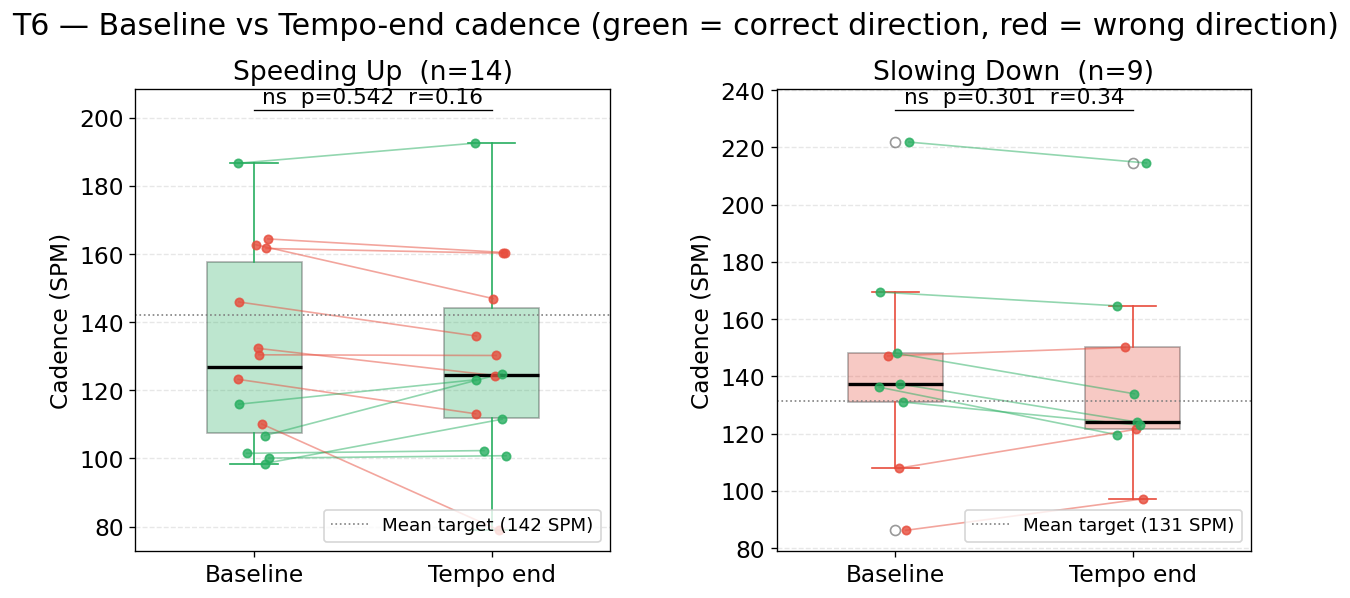

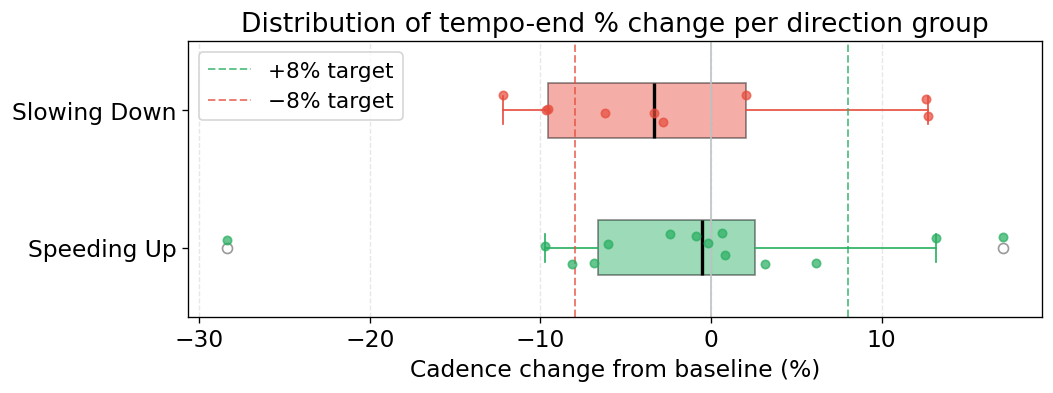

Label(value='')

In [1279]:
def compute_initial_tempo_stats():
    """
    Simple per-participant summary: baseline cadence vs cadence at the end
    of the tempo trial.  No behavioural categorisation — just raw numbers.
    """
    WIN_END = 30   # seconds at end of trial to average
    rows = []
    for pid in participants:
        path = DATA_DIR / pid / f"{pid}_pressure_tempo.csv"
        if not path.exists():
            continue
        order, direction = get_participant_meta(pid)
        if not direction:
            continue
        baseline = compute_smart_baseline(pid)["baseline_tempo"]
        if baseline is None:
            continue
        df = parse_pressure_file(path)
        if df.empty:
            continue
        grid, cad = _rolling_cadence(df, window_s=15)
        if len(grid) == 0:
            continue

        t_max = grid[-1]
        end_mask = grid >= max(0, t_max - WIN_END)
        tempo_end = float(cad[end_mask].mean()) if end_mask.sum() > 0 else float(cad[-1])

        speeding_up   = direction != "slowing down"
        target_pct    = 8.0 if speeding_up else -8.0
        pct_change    = (tempo_end - baseline) / baseline * 100.0
        correct_dir   = (pct_change > 0) == speeding_up

        rows.append({
            "pid":            pid,
            "direction":      direction,
            "order":          order,
            "baseline_spm":   round(baseline, 1),
            "tempo_end_spm":  round(tempo_end, 1),
            "pct_change":     round(pct_change, 2),
            "target_pct":     target_pct,
            "correct_direction": correct_dir,
        })
    return pd.DataFrame(rows)


# ── Compute ──────────────────────────────────────────────────────────────────
df_init = compute_initial_tempo_stats()

# ── Display 1: styled summary table ─────────────────────────────────────────
def _style_init(df):
    def _row(row):
        base = "#d5f5e3" if row["correct_direction"] else "#f9ebea"
        return [f"background-color:{base}"] * len(row)
    return (df.style
              .apply(_row, axis=1)
              .format({"baseline_spm":"{:.1f}", "tempo_end_spm":"{:.1f}",
                       "pct_change":"{:+.2f}%", "target_pct":"{:+.0f}%"}))

display(_style_init(df_init.sort_values(["direction", "pct_change"], ascending=[True, False])))

# ── Statistics ────────────────────────────────────────────────────────────────
print("\n=== Group-level cadence change ===")
DIRS = [("speeding up", "#27ae60"), ("slowing down", "#e74c3c")]
stat_rows = []
for grp, _ in DIRS:
    sub = df_init[df_init["direction"] == grp].dropna(subset=["baseline_spm","tempo_end_spm"])
    n   = len(sub)
    if n < 2:
        continue
    pct = sub["pct_change"].values
    try:
        w, p  = stats.wilcoxon(sub["baseline_spm"], sub["tempo_end_spm"])
        z     = stats.norm.ppf(p / 2)
        r_eff = abs(z) / np.sqrt(n)
    except Exception:
        w, p, r_eff = float("nan"), float("nan"), float("nan")

    n_correct = sub["correct_direction"].sum()
    med = np.median(pct)
    q1, q3 = np.percentile(pct, [25, 75])

    print(f"  {grp.title()} (n={n})")
    print(f"    Median change: {med:+.2f}%  IQR [{q1:+.2f}%, {q3:+.2f}%]")
    print(f"    Wilcoxon: W={w:.0f}, p={p:.4f}, r={r_eff:.2f}")
    print(f"    Correct direction: {n_correct}/{n} ({100*n_correct/n:.0f}%)")
    stat_rows.append({"direction":grp, "n":n, "median_pct":round(med,2),
                      "IQR_lo":round(q1,2), "IQR_hi":round(q3,2),
                      "W":round(w,0), "p":round(p,4), "r":round(r_eff,2),
                      "n_correct":n_correct})

# ── Display 2: paired boxplot ─────────────────────────────────────────────────
fig2, axes2 = plt.subplots(1, 2, figsize=(12, 5), sharey=False)
fig2.subplots_adjust(wspace=0.35)

for ax, (grp, color) in zip(axes2, DIRS):
    sub = df_init[df_init["direction"] == grp].dropna(subset=["baseline_spm","tempo_end_spm"])
    n   = len(sub)
    if n == 0:
        ax.set_title(f"{grp.title()} (n=0)"); continue

    # Boxes
    ax.boxplot([sub["baseline_spm"].values, sub["tempo_end_spm"].values],
               positions=[0, 1], widths=0.4, patch_artist=True,
               medianprops=dict(color="black", lw=2),
               boxprops=dict(facecolor=color, alpha=0.3),
               whiskerprops=dict(color=color), capprops=dict(color=color),
               flierprops=dict(marker="o", color=color, alpha=0.4))

    # Individual lines
    jitter = np.random.default_rng(0).uniform(-0.07, 0.07, n)
    for b, e, j, ok in zip(sub["baseline_spm"], sub["tempo_end_spm"],
                            jitter, sub["correct_direction"]):
        lc = "#27ae60" if ok else "#e74c3c"
        ax.plot([0+j, 1+j], [b, e], color=lc, alpha=0.5, lw=1.0, zorder=2)
        ax.scatter([0+j, 1+j], [b, e], color=lc, s=25, zorder=3, alpha=0.8)

    # Target dotted line
    mean_target = sub["baseline_spm"].mean() * (1.08 if grp=="speeding up" else 0.92)
    ax.axhline(mean_target, color="grey", lw=1.0, linestyle=":",
               label=f"Mean target ({mean_target:.0f} SPM)")

    # Stat annotation
    try:
        _, p = stats.wilcoxon(sub["baseline_spm"], sub["tempo_end_spm"])
        z    = stats.norm.ppf(p / 2)
        r    = abs(z) / np.sqrt(n)
        sig  = "***" if p<0.001 else ("**" if p<0.01 else ("*" if p<0.05 else "ns"))
        y_top = max(sub["baseline_spm"].max(), sub["tempo_end_spm"].max()) * 1.05
        ax.plot([0, 1], [y_top, y_top], color="black", lw=0.8)
        ax.text(0.5, y_top*1.005, f"{sig}  p={p:.3f}  r={r:.2f}",
                ha="center", va="bottom", fontsize=13)
    except Exception:
        pass

    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Baseline", "Tempo end"], fontsize=14)
    ax.set_ylabel("Cadence (SPM)", fontsize=14)
    ax.set_title(f"{grp.title()}  (n={n})", fontsize=16)
    ax.legend(fontsize=11, loc="lower right")
    ax.grid(axis="y", linestyle="--", alpha=0.3)

fig2.suptitle("T6 — Baseline vs Tempo-end cadence (green = correct direction, red = wrong direction)",
              fontsize=18, y=1.01)
plt.show()

# ── Display 3: % change distribution ─────────────────────────────────────────
fig3, ax3 = plt.subplots(figsize=(9, 3.5))
for i, (grp, color) in enumerate(DIRS):
    sub = df_init[df_init["direction"] == grp]["pct_change"].dropna()
    ax3.boxplot(sub.values, positions=[i], widths=0.4, vert=False, patch_artist=True,
                medianprops=dict(color="black", lw=2),
                boxprops=dict(facecolor=color, alpha=0.45),
                whiskerprops=dict(color=color), capprops=dict(color=color),
                flierprops=dict(marker="o", color=color, alpha=0.4))
    jitter = np.random.default_rng(i).uniform(-0.12, 0.12, len(sub))
    ax3.scatter(sub.values, [i]*len(sub) + jitter, color=color, s=25, alpha=0.7, zorder=3)

ax3.axvline(0,  color="#bdc3c7", lw=1.0)
ax3.axvline(8,  color="#27ae60", lw=1.2, linestyle="--", alpha=0.7, label="+8% target")
ax3.axvline(-8, color="#e74c3c", lw=1.2, linestyle="--", alpha=0.7, label="−8% target")
ax3.set_yticks([0, 1])
ax3.set_yticklabels([g.title() for g, _ in DIRS], fontsize=14)
ax3.set_xlabel("Cadence change from baseline (%)", fontsize=14)
ax3.set_title("Distribution of tempo-end % change per direction group", fontsize=16)
ax3.legend(fontsize=13)
ax3.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

# ── Export ────────────────────────────────────────────────────────────────────
init_export_btn    = widgets.Button(description="Export initial analysis",
                                     button_style="info",
                                     layout=widgets.Layout(width="190px"))
init_export_status = widgets.Label("")

def _do_init_export(_):
    d = _export_dir("initial_tempo_analysis")
    init_export_status.value = "Exporting…"

    # Paired boxplot
    fig_e, axes_e = plt.subplots(1, 2, figsize=(12, 5), sharey=False)
    fig_e.subplots_adjust(wspace=0.35)
    for ax, (grp, color) in zip(axes_e, DIRS):
        sub = df_init[df_init["direction"] == grp].dropna(subset=["baseline_spm","tempo_end_spm"])
        n = len(sub)
        if n == 0: ax.set_title(f"{grp.title()} (n=0)"); continue
        ax.boxplot([sub["baseline_spm"].values, sub["tempo_end_spm"].values],
                   positions=[0,1], widths=0.4, patch_artist=True,
                   medianprops=dict(color="black",lw=2),
                   boxprops=dict(facecolor=color,alpha=0.3),
                   whiskerprops=dict(color=color), capprops=dict(color=color),
                   flierprops=dict(marker="o",color=color,alpha=0.4))
        jit = np.random.default_rng(0).uniform(-0.07,0.07,n)
        for b,e,j,ok in zip(sub["baseline_spm"],sub["tempo_end_spm"],jit,sub["correct_direction"]):
            lc = "#27ae60" if ok else "#e74c3c"
            ax.plot([0+j,1+j],[b,e],color=lc,alpha=0.5,lw=1.0,zorder=2)
            ax.scatter([0+j,1+j],[b,e],color=lc,s=25,zorder=3,alpha=0.8)
        mt = sub["baseline_spm"].mean()*(1.08 if grp=="speeding up" else 0.92)
        ax.axhline(mt,color="grey",lw=1.0,linestyle=":")
        try:
            _,p = stats.wilcoxon(sub["baseline_spm"],sub["tempo_end_spm"])
            z = stats.norm.ppf(p/2); r = abs(z)/np.sqrt(n)
            sig = "***" if p<0.001 else ("**" if p<0.01 else ("*" if p<0.05 else "ns"))
            yt = max(sub["baseline_spm"].max(),sub["tempo_end_spm"].max())*1.05
            ax.plot([0,1],[yt,yt],color="black",lw=0.8)
            ax.text(0.5,yt*1.005,f"{sig}  p={p:.3f}  r={r:.2f}",ha="center",va="bottom",fontsize=13)
        except: pass
        ax.set_xticks([0,1]); ax.set_xticklabels(["Baseline","Tempo end"],fontsize=14)
        ax.set_ylabel("Cadence (SPM)",fontsize=14); ax.set_title(f"{grp.title()}  (n={n})",fontsize=16)
        ax.grid(axis="y",linestyle="--",alpha=0.3)
    fig_e.suptitle("T6 — Baseline vs Tempo-end cadence",fontsize=18,y=1.01)
    plt.tight_layout()
    _save_fig(fig_e, d / "baseline_vs_tempo_end.png"); plt.close(fig_e)

    # % change distribution figure
    fig_d, ax_d = plt.subplots(figsize=(9, 3.5))
    for i, (grp, color) in enumerate(DIRS):
        sub_d = df_init[df_init["direction"] == grp]["pct_change"].dropna()
        ax_d.boxplot(sub_d.values, positions=[i], widths=0.4, vert=False,
                     patch_artist=True,
                     medianprops=dict(color="black", lw=2),
                     boxprops=dict(facecolor=color, alpha=0.45),
                     whiskerprops=dict(color=color), capprops=dict(color=color),
                     flierprops=dict(marker="o", color=color, alpha=0.4))
        jit_d = np.random.default_rng(i).uniform(-0.12, 0.12, len(sub_d))
        ax_d.scatter(sub_d.values, [i]*len(sub_d) + jit_d,
                     color=color, s=25, alpha=0.7, zorder=3)
    ax_d.axvline(0,  color="#bdc3c7", lw=1.0)
    ax_d.axvline(8,  color="#27ae60", lw=1.2, linestyle="--", alpha=0.7, label="+8% target")
    ax_d.axvline(-8, color="#e74c3c", lw=1.2, linestyle="--", alpha=0.7, label="-8% target")
    ax_d.set_yticks([0, 1])
    ax_d.set_yticklabels([g.title() for g, _ in DIRS], fontsize=14)
    ax_d.set_xlabel("Cadence change from baseline (%)", fontsize=14)
    ax_d.set_title("Distribution of tempo-end % change per direction group", fontsize=16)
    ax_d.legend(fontsize=13)
    ax_d.grid(axis="x", linestyle="--", alpha=0.3)
    plt.tight_layout()
    _save_fig(fig_d, d / "pct_change_distribution.png")
    plt.close(fig_d)

    # CSV
    df_init.to_csv(d / "initial_tempo_stats.csv", index=False)
    pd.DataFrame(stat_rows).to_csv(d / "group_stats.csv", index=False)

    init_export_status.value = "✓ Saved to exports/initial_tempo_analysis/"
    print("Saved: baseline_vs_tempo_end.png, pct_change_distribution.png, initial_tempo_stats.csv, group_stats.csv")

init_export_btn.on_click(_do_init_export)
display(widgets.HBox([init_export_btn]), init_export_status)


## Per-session cadence–audio coupling

One panel per session: cadence (BPM) over trial time, with a linear regression fit overlaid across the **active manipulation window** (where the audio scale factor has moved more than 2% from baseline). Panels are sorted by coupling strength (positive slope = cadence tracked the audio). Blue = speeding up, red = slowing down.

Sessions with active window data: 23
Positive coupling (slope>0): 9/23


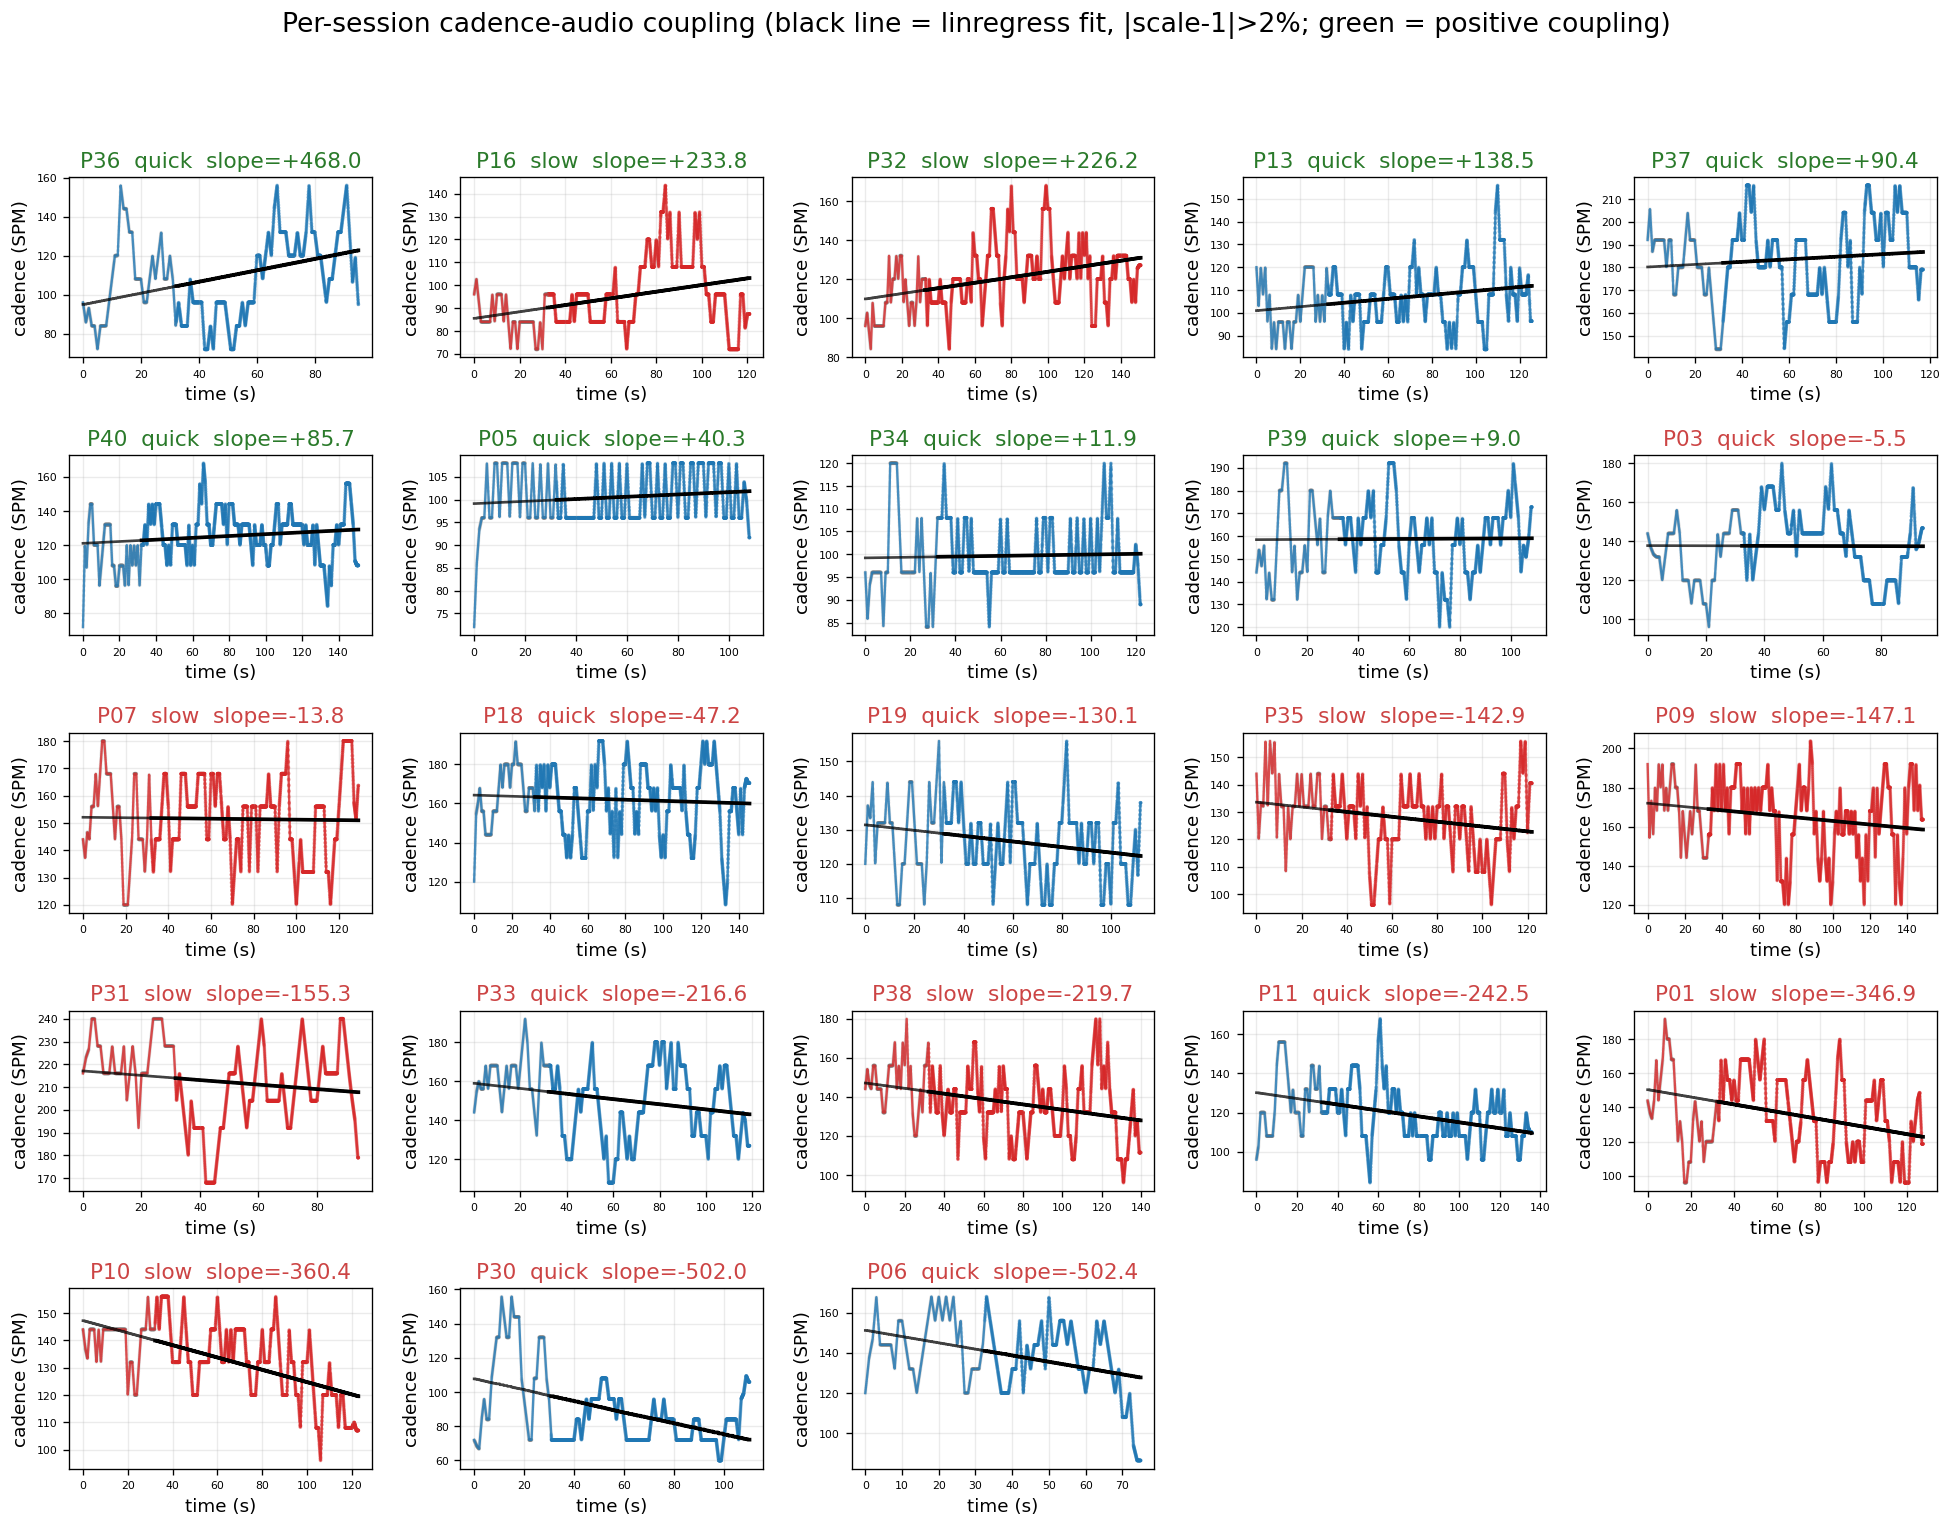

Label(value='')

In [1280]:
def _build_linreg_sessions(window_s=5):
    """
    For each tempo session, interpolate rolling cadence onto the scale-factor
    time grid, identify the active manipulation window (|scale-1| > 0.02),
    fit linregress(scale, cadence) in that window, and return a list of dicts
    sorted by coupling strength (slope, unsigned).
    """
    sessions = []
    for pid in participants:
        path_p = DATA_DIR / pid / f"{pid}_pressure_tempo.csv"
        path_s = DATA_DIR / pid / f"{pid}_pressure_tempo.csv"
        if not path_p.exists():
            continue
        order, direction = get_participant_meta(pid)
        if not direction:
            continue
        baseline = compute_smart_baseline(pid)["baseline_tempo"]
        if baseline is None:
            continue

        # ── Scale factor from tempo SPM file ────────────────────────────────
        spm_df = parse_tempo_spm(path_p)
        if spm_df.empty or "scale" not in spm_df.columns:
            continue
        scale_t   = spm_df["time_s"].to_numpy()
        scale_raw = spm_df["scale"].to_numpy().astype(float)
        if len(scale_t) < 10:
            continue

        # ── Rolling cadence at finer window (more temporal detail) ──────────
        df = parse_pressure_file(path_p)
        if df.empty:
            continue
        grid, cad = _rolling_cadence(df, window_s=window_s)
        if len(grid) == 0:
            continue

        # Interpolate cadence onto scale time grid
        cad_interp = np.interp(scale_t, grid, cad)

        # ── Active window: audio has shifted >2% from baseline ───────────────
        active = np.abs(scale_raw - 1.0) > 0.02
        if active.sum() < 5:
            continue

        # ── Linear regression: scale (x) vs cadence (y) in active window ────
        # Regression over full trial — all scale/cadence pairs
        x = scale_raw
        y = cad_interp
        from scipy.stats import linregress as _lr
        fit = _lr(x, y)

        # coupling: positive slope = cadence tracks scale in same direction
        speeding_up = direction != "slowing down"
        # For speeding-up: scale > 1 & cadence up → slope > 0 = good
        # For slowing-down: scale < 1 & cadence down → slope > 0 = good (same)
        coupling = float(fit.slope)

        sessions.append({
            "pid":        pid,
            "direction":  direction,
            "scale_t":    scale_t,
            "scale_raw":  scale_raw,
            "cad_interp": cad_interp,
            "active":     active,
            "slope":      float(fit.slope),
            "intercept":  float(fit.intercept),
            "coupling":   coupling,
            "speeding_up": speeding_up,
        })

    sessions.sort(key=lambda s: -s["coupling"])
    return sessions


def _draw_linreg_grid(sessions, save_path=None):
    ncols = 5
    nrows = int(np.ceil(len(sessions) / ncols))
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(3.3 * ncols, 2.6 * nrows),
                             squeeze=False)
    for ax in axes.ravel():
        ax.axis("off")

    for ax, d in zip(axes.ravel(), sessions):
        ax.axis("on")
        color = "#1f77b4" if d["speeding_up"] else "#d62728"
        a = d["active"]
        t = d["scale_t"]

        # Scatter: active window colored, inactive grey
        ax.scatter(t[a],  d["cad_interp"][a],  s=5, alpha=0.30,
                   color=color, edgecolors="none")
        ax.scatter(t[~a], d["cad_interp"][~a], s=5, alpha=0.10,
                   color="gray", edgecolors="none")

        # Rolling cadence line
        ax.plot(t, d["cad_interp"], color=color, lw=1.4, alpha=0.8)

        # Regression fit line extended across full trial
        fit_y = d["intercept"] + d["slope"] * d["scale_raw"]
        ax.plot(t, fit_y, color="black", lw=1.6, alpha=0.75)
        # Highlight the active portion
        ax.plot(t[a], fit_y[a], color="black", lw=2.2)

        good = d["coupling"] > 0
        title_color = "#2a7a2a" if good else "#c44"
        ax.set_title(
            'P{}  {}  slope={:+.1f}'.format(d['pid'], {'speeding up': 'quick', 'slowing down': 'slow'}.get(d['direction'], d['direction'][:5]), d['slope']),
            fontsize=13, color=title_color
        )
        ax.set_xlabel("time (s)", fontsize=11)
        ax.set_ylabel("cadence (SPM)", fontsize=11)
        ax.tick_params(labelsize=6.5)
        ax.grid(alpha=0.25)

    fig.suptitle(
        "Per-session cadence-audio coupling (black line = linregress fit, |scale-1|>2%; green = positive coupling)",
        fontsize=16
    )
    fig.tight_layout(rect=(0, 0, 1, 0.94))
    if save_path:
        _save_fig(fig, save_path)
    return fig


# ── Build + render ────────────────────────────────────────────────────────────
_lr_sessions = _build_linreg_sessions(window_s=5)
print(f"Sessions with active window data: {len(_lr_sessions)}")
print(f"Positive coupling (slope>0): {sum(1 for s in _lr_sessions if s['coupling']>0)}/{len(_lr_sessions)}")
fig_lr = _draw_linreg_grid(_lr_sessions)
plt.show()

# ── Export button ─────────────────────────────────────────────────────────────
lr_export_btn    = widgets.Button(description="Export panel grid",
                                   button_style="info",
                                   layout=widgets.Layout(width="160px"))
lr_export_status = widgets.Label("")

def _do_lr_export(_):
    d = _export_dir("f2_asymmetry")
    lr_export_status.value = "Exporting…"
    _draw_linreg_grid(_lr_sessions, save_path=d / "linreg_per_session.png")
    plt.close()
    lr_export_status.value = "✓ Saved to exports/f2_asymmetry/linreg_per_session.png"

lr_export_btn.on_click(_do_lr_export)
display(widgets.HBox([lr_export_btn]), lr_export_status)


## Tempo cadence analysis

In [1281]:
# Build category map: label → {pids, direction}
_tempo_categories = {}
for _pid in participants:
    if not (DATA_DIR / _pid / f"{_pid}_pressure_tempo.csv").exists():
        continue
    _order, _direction = get_participant_meta(_pid)
    if not _direction:
        continue
    if compute_smart_baseline(_pid)["baseline_tempo"] is None:
        continue
    _label = f"{_direction.title()} — {_order}"
    _tempo_categories.setdefault(_label, {"pids": [], "direction": _direction})
    _tempo_categories[_label]["pids"].append(_pid)

_cat_options = sorted([f"{lbl}  (n={len(v['pids'])})" for lbl, v in _tempo_categories.items()])
_cat_lookup  = {f"{lbl}  (n={len(v['pids'])})": (v["pids"], v["direction"])
                for lbl, v in _tempo_categories.items()}

cat_sel = widgets.Dropdown(
    options=_cat_options, value=_cat_options[0] if _cat_options else "",
    description="Category:",
    style={"description_width": "70px"},
    layout=widgets.Layout(width="320px"),
)
tempo_window_slider = widgets.IntSlider(
    min=5, max=60, step=5, value=15,
    description="Window (s):",
    style={"description_width": "80px"},
    layout=widgets.Layout(width="280px"),
)
export_btn    = widgets.Button(description="Export plots", button_style="info",
                               layout=widgets.Layout(width="140px"))
export_status = widgets.Label("")
out_tempo     = widgets.Output()


def _render_category(pid_list, direction, window_s, cat_label, save_dir=None):
    """Render individual plots then the combined overlay. Optionally save to save_dir."""
    # ── individual plots ──
    for pid in pid_list:
        order, _ = get_participant_meta(pid)
        baseline = compute_smart_baseline(pid)["baseline_tempo"]
        if baseline is None:
            continue
        df = parse_pressure_file(DATA_DIR / pid / f"{pid}_pressure_tempo.csv")
        if df.empty:
            continue
        sp = (save_dir / f"{pid}_individual.png") if save_dir else None
        plot_tempo_achievement(
            df, baseline, direction, window_s,
            title=f"T6 — P{pid}  |  {cat_label.split('(')[0].strip()}",
            save_path=sp,
        )

    # ── combined overlay ──
    sp = (save_dir / "combined_overlay.png") if save_dir else None
    plot_category_achievement(
        pid_list, direction, window_s,
        title=f"T6  |  Combined  |  {cat_label}",
        save_path=sp,
    )


def refresh_tempo(_=None):
    out_tempo.clear_output(wait=True)
    cat = cat_sel.value
    if not cat or cat not in _cat_lookup:
        return
    pid_list, direction = _cat_lookup[cat]
    with out_tempo:
        _render_category(pid_list, direction, tempo_window_slider.value, cat)


def do_export(_):
    cat = cat_sel.value
    if not cat or cat not in _cat_lookup:
        return
    pid_list, direction = _cat_lookup[cat]
    safe = (cat.replace(" ", "_").replace("(", "").replace(")", "")
              .replace("—", "-").replace("/", "-").strip("_- "))
    save_dir = DATA_DIR / "exports" / safe
    save_dir.mkdir(parents=True, exist_ok=True)
    export_status.value = f"Exporting {len(pid_list)} sessions…"
    out_tempo.clear_output(wait=True)
    with out_tempo:
        _render_category(pid_list, direction, tempo_window_slider.value, cat,
                         save_dir=save_dir)
    export_status.value = f"✓ Saved to exports/{safe}/"


export_btn.on_click(do_export)
cat_sel.observe(refresh_tempo, names="value")
tempo_window_slider.observe(refresh_tempo, names="value")
display(widgets.HBox([cat_sel, tempo_window_slider, export_btn]), export_status, out_tempo)
refresh_tempo()

Label(value='')

Output()

## Average cadence trajectories by group

Mean % change from individual baseline across all participants in each of the four groups (direction × condition order). The shaded band shows ±1 SEM. The dashed line is the trapezoid target ramp (0→±8%). Use the export button to save all four subplots as a single figure.

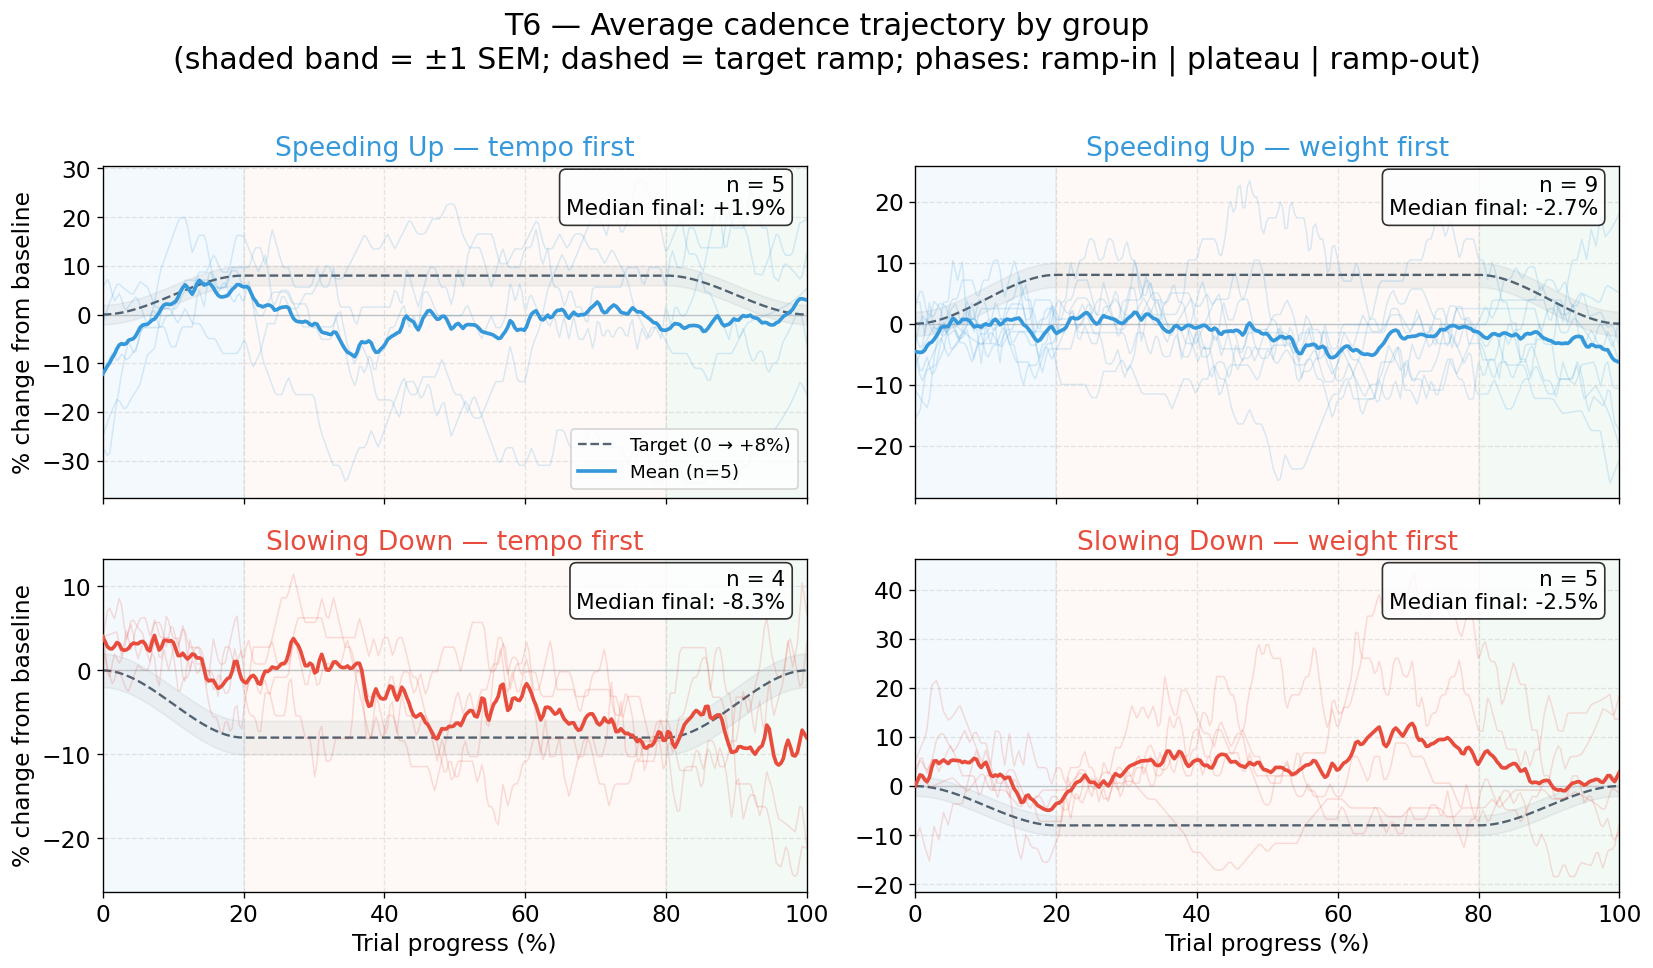

Label(value='')

In [1282]:
FADE_FRAC = 0.20   # must match _trapezoid_target_pct fade_frac default

def _build_avg_trajectories():
    """
    For each of the 4 groups (direction × order), compute the mean ± SEM
    cadence trajectory (as % change from individual baseline) on a common
    0–100% normalised time grid.  Returns a dict keyed by group label.
    """
    COMMON_GRID = np.linspace(0, 1, 300)
    result = {}

    for label, meta in _tempo_categories.items():
        pids      = meta["pids"]
        direction = meta["direction"]
        speeding_up = direction != "slowing down"
        target_sign = 1.0 if speeding_up else -1.0

        curves = []
        for pid in pids:
            baseline = compute_smart_baseline(pid)["baseline_tempo"]
            if baseline is None:
                continue
            df = parse_pressure_file(DATA_DIR / pid / f"{pid}_pressure_tempo.csv")
            if df.empty:
                continue
            grid, cad = _rolling_cadence(df, window_s=15)
            if len(grid) == 0:
                continue
            t_n  = grid / grid[-1]
            pct  = (cad / baseline - 1.0) * 100.0
            curves.append(np.interp(COMMON_GRID, t_n, pct))

        if not curves:
            result[label] = None
            continue

        arr       = np.array(curves)
        mean_c    = arr.mean(axis=0)
        sem_c     = arr.std(axis=0) / np.sqrt(len(curves))
        final_pct = float(np.median(arr[:, -20:].mean(axis=1)))  # median of last ~7%

        result[label] = {
            "mean":       mean_c,
            "sem":        sem_c,
            "curves":     list(arr),
            "n":          len(curves),
            "direction":  direction,
            "target_sign": target_sign,
            "final_pct":  final_pct,
            "label":      label,
        }
    return result, COMMON_GRID


def _draw_avg_2x2(save_path=None):
    """Render the 2×2 average-trajectory figure.  Returns the figure object."""
    data, t_common = _build_avg_trajectories()

    # Order: rows = direction, cols = condition order
    ROWS = ["speeding up", "slowing down"]
    COLS = ["tempo first", "weight first"]
    DIR_COLOR = {"speeding up": "#3498db", "slowing down": "#e74c3c"}

    fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharey=False, sharex=True)
    fig.subplots_adjust(hspace=0.38, wspace=0.28)

    t_pct = t_common * 100   # 0–100%

    # Phase bands
    PHASE_BANDS = [
        (0,              FADE_FRAC*100,       "#3498db", 0.05),
        (FADE_FRAC*100,  (1-FADE_FRAC)*100,   "#e67e22", 0.04),
        ((1-FADE_FRAC)*100, 100,              "#27ae60", 0.05),
    ]

    for ri, direction in enumerate(ROWS):
        for ci, order in enumerate(COLS):
            ax = axes[ri][ci]
            color = DIR_COLOR[direction]

            # Find matching group label
            key = next(
                (k for k, v in data.items()
                 if v is not None
                 and v["direction"] == direction
                 and order in k.lower()),
                None
            )

            # Phase shading
            for x0, x1, c, alpha in PHASE_BANDS:
                ax.axvspan(x0, x1, alpha=alpha, color=c)

            ax.axhline(0, color="#bdc3c7", lw=0.8)

            if key is None or data[key] is None:
                ax.text(0.5, 0.5, "No data", ha="center", va="center",
                        transform=ax.transAxes, color="gray", fontsize=18)
                ax.set_title(f"{direction.title()} — {order}", fontsize=16)
                continue

            d     = data[key]
            mean  = d["mean"]
            sem   = d["sem"]
            n     = d["n"]
            ts    = d["target_sign"]

            # Target ramp
            target = _trapezoid_target_pct(t_common, ts)
            ax.plot(t_pct, target, color="#2c3e50", lw=1.4, linestyle="--",
                    alpha=0.8, label=f"Target (0 → {ts*8:+.0f}%)")
            ax.fill_between(t_pct, target - 2, target + 2,
                            color="#2c3e50", alpha=0.06)

            # Individual curves (transparent) + mean
            for curve in d["curves"]:
                ax.plot(t_pct, curve, color=color, alpha=0.18, lw=0.9, zorder=2)
            ax.plot(t_pct, mean, color=color, lw=2.2, zorder=4, label=f"Mean (n={n})")

            # Annotation
            ax.text(0.97, 0.97,
                    f"n = {n}\nMedian final: {d['final_pct']:+.1f}%",
                    transform=ax.transAxes, fontsize=13, va="top", ha="right",
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

            ax.set_title(f"{direction.title()} — {order}", fontsize=16, color=color)
            ax.set_xlim(0, 100)
            ax.grid(linestyle="--", alpha=0.3)
            if ri == 1:
                ax.set_xlabel("Trial progress (%)", fontsize=14)
            if ci == 0:
                ax.set_ylabel("% change from baseline", fontsize=14)

            # Legend only on first subplot
            if ri == 0 and ci == 0:
                ax.legend(fontsize=11, loc="lower right")

    fig.suptitle(
        "T6 — Average cadence trajectory by group\n"
        "(shaded band = ±1 SEM; dashed = target ramp; phases: ramp-in | plateau | ramp-out)",
        fontsize=18, y=1.01
    )
    plt.tight_layout()
    if save_path:
        _save_fig(fig, save_path)
    return fig


# ── Render ────────────────────────────────────────────────────────────────────
fig_avg = _draw_avg_2x2()
plt.show()

# ── Export button ─────────────────────────────────────────────────────────────
avg_export_btn    = widgets.Button(description="Export 2×2 figure",
                                    button_style="info",
                                    layout=widgets.Layout(width="160px"))
avg_export_status = widgets.Label("")

def _do_avg_export(_):
    d = _export_dir("tempo_average_trajectories")
    avg_export_status.value = "Exporting…"
    _draw_avg_2x2(save_path=d / "average_trajectories_2x2.png")
    plt.close()
    avg_export_status.value = "✓ Saved to exports/tempo_average_trajectories/"

avg_export_btn.on_click(_do_avg_export)
display(widgets.HBox([avg_export_btn]), avg_export_status)


## Gait quality analysis — weight condition

In [1283]:
gait_participants = [p for p in participants
    if (DATA_DIR / p / f"{p}_imu_L.csv").exists()
    and (DATA_DIR / p / f"{p}_imu_R.csv").exists()]
init_gait_pid = gait_participants[0] if gait_participants else ""

pid_gait           = widgets.Dropdown(options=gait_participants, value=init_gait_pid,
                                       description="Participant:", style={"description_width": "90px"},
                                       layout=widgets.Layout(width="200px"))
ma_slider          = widgets.IntSlider(min=1, max=20, step=1, value=5,
                                        description="Moving avg (steps):", style={"description_width": "130px"},
                                        layout=widgets.Layout(width="340px"))
gait_export_btn    = widgets.Button(description="Export plots", button_style="info",
                                     layout=widgets.Layout(width="130px"))
gait_export_status = widgets.Label("")
out_gait           = widgets.Output()

def refresh_gait(_=None):
    pid = pid_gait.value
    out_gait.clear_output(wait=True)
    with out_gait:
        imu_L = load_imu(pid, "L"); imu_R = load_imu(pid, "R")
        order, _ = get_participant_meta(pid)
        weight_dir = get_weight_direction(pid)
        meta_parts = [p for p in [order, f"weight {weight_dir}" if weight_dir else ""] if p]
        meta = ("  |  " + "  |  ".join(meta_parts)) if meta_parts else ""
        plot_gait_quality(imu_L, imu_R, ma_slider.value,
                          title=f"T6 — P{pid}  |  gait quality{meta}")

def do_gait_export(_):
    pid = pid_gait.value
    safe = f"gait_quality_{pid}"
    d    = _export_dir(safe)
    gait_export_status.value = "Exporting…"
    imu_L = load_imu(pid, "L"); imu_R = load_imu(pid, "R")
    order, _ = get_participant_meta(pid)
    weight_dir = get_weight_direction(pid)
    meta_parts = [p for p in [order, f"weight {weight_dir}" if weight_dir else ""] if p]
    meta = ("  |  " + "  |  ".join(meta_parts)) if meta_parts else ""
    plot_gait_quality(imu_L, imu_R, ma_slider.value,
                      title=f"T6 — P{pid}  |  gait quality{meta}",
                      save_path=d / "gait_quality.png")
    gait_export_status.value = f"✓ Saved to exports/{safe}/"

gait_export_btn.on_click(do_gait_export)
pid_gait.observe(refresh_gait, names="value")
ma_slider.observe(refresh_gait, names="value")
display(widgets.HBox([pid_gait, ma_slider, gait_export_btn]), gait_export_status, out_gait)
refresh_gait()

Label(value='')

Output()

## Group cadence analysis — tempo effect

Aggregates all participants. Cadence at three time points (baseline, tempo start, tempo end) is compared within each direction subgroup (speeding up / slowing down) using paired Wilcoxon signed-rank tests.

**Interpretation guide**
- *Baseline → Tempo start*: manipulation check — should be near zero (participant just started, no change yet)
- *Baseline → Tempo end*: primary test — did the device successfully shift cadence by ~8%?
- *Effect size r*: |Z| / √N — small ≥ 0.1, medium ≥ 0.3, large ≥ 0.5
- *% achieved*: 100% = participant's cadence reached the exact ±8% target by the end

=== Summary table ===

SPEEDING UP  (n=14)
  Baseline:    median=126.8  IQR=[107.6, 157.7]
  Tempo end:   median=124.6  IQR=[111.9, 144.1]
  Wilcoxon:    p=0.5416  r=0.163
  % achieved:  median=-7%  IQR=[-83%, 32%]

SLOWING DOWN  (n=9)
  Baseline:    median=137.3  IQR=[131.0, 148.0]
  Tempo end:   median=124.0  IQR=[121.5, 150.1]
  Wilcoxon:    p=0.3008  r=0.345
  % achieved:  median=41%  IQR=[-26%, 119%]


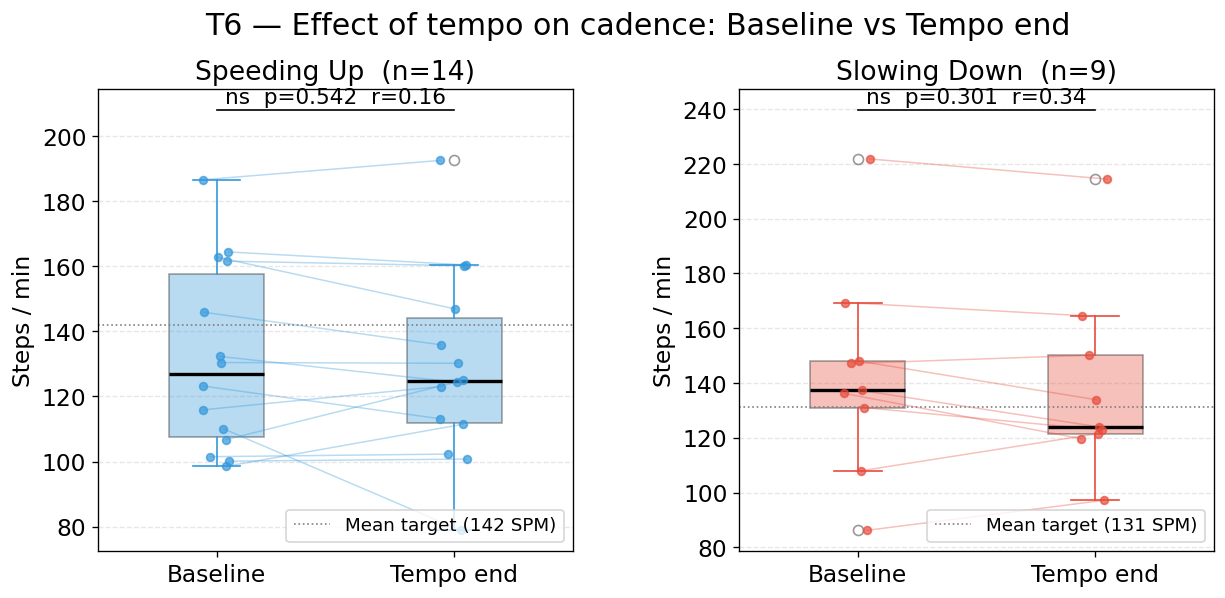

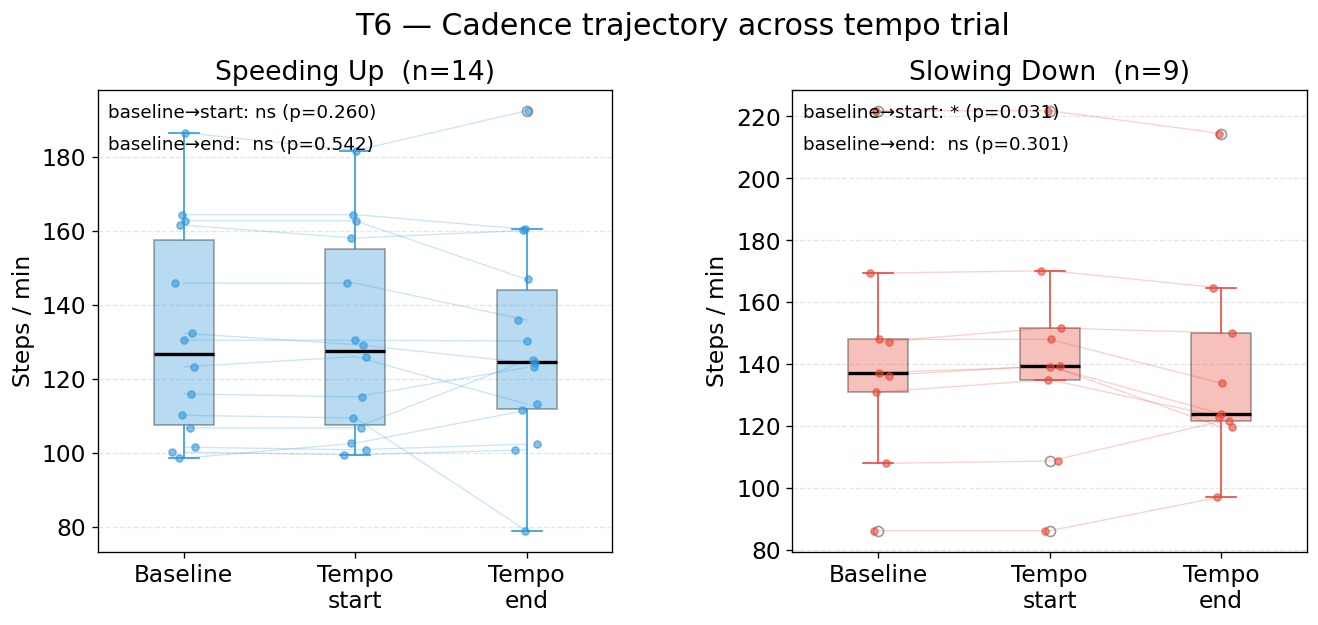

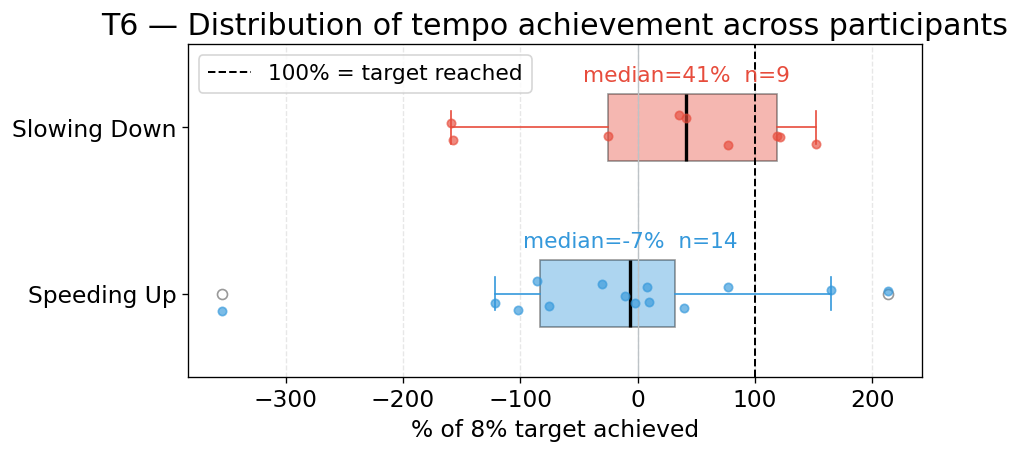

In [1284]:
df_group = build_group_stats()

# summary table
print("=== Summary table ===")
for grp in ("speeding up", "slowing down"):
    sub = df_group[df_group["direction"] == grp].dropna(
        subset=["baseline_spm", "tempo_end_spm", "pct_achieved"])
    if sub.empty:
        continue
    _, p = stats.wilcoxon(sub["baseline_spm"], sub["tempo_end_spm"])
    z  = stats.norm.ppf(p / 2)
    r  = abs(z) / np.sqrt(len(sub))
    print(f"\n{grp.upper()}  (n={len(sub)})")
    print(f"  Baseline:    median={sub['baseline_spm'].median():.1f}  "
          f"IQR=[{sub['baseline_spm'].quantile(0.25):.1f}, {sub['baseline_spm'].quantile(0.75):.1f}]")
    print(f"  Tempo end:   median={sub['tempo_end_spm'].median():.1f}  "
          f"IQR=[{sub['tempo_end_spm'].quantile(0.25):.1f}, {sub['tempo_end_spm'].quantile(0.75):.1f}]")
    print(f"  Wilcoxon:    p={p:.4f}  r={r:.3f}")
    print(f"  % achieved:  median={sub['pct_achieved'].median():.0f}%  "
          f"IQR=[{sub['pct_achieved'].quantile(0.25):.0f}%, {sub['pct_achieved'].quantile(0.75):.0f}%]")

plot_tempo_group_analysis(df_group)

In [1285]:
grp_export_btn    = widgets.Button(description="Export group plots", button_style="info",
                                    layout=widgets.Layout(width="170px"))
grp_export_status = widgets.Label("")

def do_grp_export(_):
    d = _export_dir("group_analysis")
    grp_export_status.value = "Exporting 3 figures…"

    UP, DOWN = "#3498db", "#e74c3c"
    GROUPS   = [("speeding up", UP), ("slowing down", DOWN)]

    # Figure 1: Baseline vs Tempo end
    fig1, axes1 = plt.subplots(1, 2, figsize=(12, 5), sharey=False)
    fig1.subplots_adjust(wspace=0.35)
    for ax, (grp, color) in zip(axes1, GROUPS):
        sub = df_group[df_group["direction"] == grp].dropna(subset=["baseline_spm","tempo_end_spm"])
        n   = len(sub)
        if n == 0: ax.set_title(f"{grp.title()} (n=0)"); continue
        ax.boxplot([sub["baseline_spm"].values, sub["tempo_end_spm"].values],
                   positions=[0,1], widths=0.4, patch_artist=True,
                   medianprops=dict(color="black",lw=2),
                   boxprops=dict(facecolor=color,alpha=0.35),
                   whiskerprops=dict(color=color), capprops=dict(color=color),
                   flierprops=dict(marker="o",color=color,alpha=0.4))
        jitter = np.random.default_rng(0).uniform(-0.06, 0.06, n)
        for b, e, j in zip(sub["baseline_spm"], sub["tempo_end_spm"], jitter):
            ax.plot([0+j,1+j],[b,e],color=color,alpha=0.35,lw=0.9,zorder=2)
            ax.scatter([0+j,1+j],[b,e],color=color,s=22,zorder=3,alpha=0.7)
        ax.axhline(sub["target_spm"].mean(), color="grey", lw=1.0, linestyle=":")
        _, p_val = stats.wilcoxon(sub["baseline_spm"], sub["tempo_end_spm"])
        z = stats.norm.ppf(p_val/2); r = abs(z)/np.sqrt(n)
        sig = "***" if p_val<0.001 else ("**" if p_val<0.01 else ("*" if p_val<0.05 else "ns"))
        y_top = max(sub["baseline_spm"].max(), sub["tempo_end_spm"].max()) * 1.08
        ax.plot([0,1],[y_top,y_top],color="black",lw=1.0)
        ax.text(0.5,y_top*1.005,f"{sig}  p={p_val:.3f}  r={r:.2f}",ha="center",va="bottom",fontsize=13)
        ax.set_xticks([0,1]); ax.set_xticklabels(["Baseline","Tempo end"],fontsize=14)
        ax.set_ylabel("Steps / min",fontsize=14); ax.set_title(f"{grp.title()}  (n={n})",fontsize=16)
        ax.grid(axis="y",linestyle="--",alpha=0.3)
    fig1.suptitle("T6 — Effect of tempo on cadence: Baseline vs Tempo end",fontsize=18,y=1.01)
    plt.tight_layout(); _save_fig(fig1, d/"fig1_baseline_vs_end.png"); plt.close(fig1)

    # Figure 2: % achieved
    fig3, ax3 = plt.subplots(figsize=(8, 4))
    for i, (grp, color) in enumerate(GROUPS):
        sub = df_group[df_group["direction"] == grp]["pct_achieved"].dropna()
        ax3.boxplot(sub.values, positions=[i], widths=0.4, vert=False, patch_artist=True,
                    medianprops=dict(color="black",lw=2), boxprops=dict(facecolor=color,alpha=0.40),
                    whiskerprops=dict(color=color), capprops=dict(color=color),
                    flierprops=dict(marker="o",color=color,alpha=0.4))
        jitter = np.random.default_rng(2).uniform(-0.12, 0.12, len(sub))
        ax3.scatter(sub.values, [i]*len(sub)+jitter, color=color, s=25, alpha=0.65, zorder=3)
    ax3.axvline(100, color="black", lw=1.2, linestyle="--", label="100% = target reached")
    ax3.axvline(0,   color="#bdc3c7", lw=0.8)
    ax3.set_yticks([0,1]); ax3.set_yticklabels([g.title() for g,_ in GROUPS],fontsize=14)
    ax3.set_xlabel("% of 8% target achieved",fontsize=14)
    ax3.set_title("T6 — Distribution of tempo achievement",fontsize=18)
    ax3.legend(fontsize=13); ax3.grid(axis="x",linestyle="--",alpha=0.3)
    plt.tight_layout(); _save_fig(fig3, d/"fig2_pct_achieved.png"); plt.close(fig3)

    grp_export_status.value = "✓ Saved to exports/group_analysis/"

grp_export_btn.on_click(do_grp_export)
display(widgets.HBox([grp_export_btn]), grp_export_status)

Label(value='')

## Directional bias — tempo condition

Compares the direction-corrected cadence response during the **ramp-in phase** (0–20% of trial)
vs the **plateau phase** (20–80%), split by manipulation direction (speeding up / slowing down).
Mirrors the weight directional bias analysis in `t6_weight_gait_analysis.ipynb`.

Positive values = cadence moved toward the target direction.

In [1286]:
from scipy import stats as _sp_stats

_TEMPO_ROLL_WIN_S = 15    # rolling cadence window (s) — matches FADE_FRAC analysis
_SF_MANIP_THR     = 0.01  # |scale_factor – 1| above this → manipulation is active


def _tempo_baseline_sd(pid):
    """
    Estimate cadence SD from the smart-baseline windows for this participant.
    Uses the same windows as compute_smart_baseline so the SD is consistent
    with the mean baseline used throughout the tempo analysis.
    """
    result = compute_smart_baseline(pid)
    order, _ = get_participant_meta(pid)
    weight_first = order.startswith("weight")
    target_group = 2 if weight_first else 1
    windows = [w for w in result["windows"]
               if w["group"] == target_group and w["included"]]
    cadences = []
    for w in windows:
        df = parse_pressure_file(DATA_DIR / pid / f"{pid}_pressure_{w['phase']}.csv")
        if df.empty:
            continue
        grid, cad = _rolling_cadence(df, window_s=_TEMPO_ROLL_WIN_S)
        mask = (grid >= w["t_start"]) & (grid <= w["t_end"])
        if mask.sum() >= 3:
            cadences.extend(cad[mask].tolist())
    return max(float(np.std(cadences)), 0.1) if len(cadences) >= 3 else 1.0


def _compute_tempo_phase_z(pid):
    """
    Per-session directional bias metrics for the tempo condition.

    The manipulation window is identified from the scale_factor signal
    (|scale – 1| > _SF_MANIP_THR). Time within the manipulation window is
    normalised to [0, 1] and split into three phases using FADE_FRAC:
        ramp-in  : 0 – FADE_FRAC
        plateau  : FADE_FRAC – (1 – FADE_FRAC)
        ramp-out : (1 – FADE_FRAC) – 1

    Cadence is z-scored relative to the smart-baseline mean and SD, then
    direction-corrected (positive = moved toward target).
    Returns a dict, or None if data are unavailable.
    """
    order, direction = get_participant_meta(pid)
    if not direction or direction.lower() in ("nan", ""):
        return None

    df_press = parse_pressure_file(DATA_DIR / pid / f"{pid}_pressure_tempo.csv")
    if df_press.empty:
        return None

    df_sf = parse_tempo_spm(DATA_DIR / pid / f"{pid}_pressure_tempo.csv")
    if df_sf.empty:
        return None

    sf   = df_sf["scale"].to_numpy().astype(float)
    t_sf = df_sf["time_s"].to_numpy()
    manip_mask = np.abs(sf - 1.0) > _SF_MANIP_THR
    manip_idxs = np.where(manip_mask)[0]

    if len(manip_idxs) < 10:
        # scale_factor never clearly deviates — treat whole session as manipulation
        t_start, t_end = 0.0, float(t_sf[-1])
    else:
        t_start = float(t_sf[manip_idxs[0]])
        t_end   = float(t_sf[manip_idxs[-1]])

    grid, cadence = _rolling_cadence(df_press, window_s=_TEMPO_ROLL_WIN_S)
    if len(grid) < 10:
        return None

    bl_result     = compute_smart_baseline(pid)
    baseline_mean = bl_result.get("baseline_tempo") or bl_result.get("baseline_1")
    if baseline_mean is None:
        return None
    baseline_sd = _tempo_baseline_sd(pid)

    manip_time_mask = (grid >= t_start) & (grid <= t_end)
    if manip_time_mask.sum() < 10:
        return None
    c_m    = cadence[manip_time_mask]
    t_m    = grid[manip_time_mask]
    t_norm = (t_m - t_m[0]) / (t_m[-1] - t_m[0])

    sign = +1.0 if "speed" in direction.lower() else -1.0
    z    = (c_m - float(baseline_mean)) / baseline_sd * sign

    def _phase_mean(mask):
        return float(np.mean(z[mask])) if mask.sum() > 0 else np.nan

    ramp_resp = _phase_mean(t_norm <= FADE_FRAC)
    plat_resp = _phase_mean((t_norm > FADE_FRAC) & (t_norm < 1.0 - FADE_FRAC))
    rout_resp = _phase_mean(t_norm >= 1.0 - FADE_FRAC)

    return dict(
        pid              = pid,
        direction        = direction,
        order            = order,
        ramp_response    = ramp_resp,
        plateau_response = plat_resp,
        ramp_out         = rout_resp,
        bias_index       = ramp_resp - plat_resp,
        baseline_mean    = float(baseline_mean),
        baseline_sd      = baseline_sd,
    )


def build_tempo_phase_stats():
    """Aggregate per-session phase z-scores for all tempo participants."""
    rows = [r for pid in participants
            if (r := _compute_tempo_phase_z(pid)) is not None]
    return pd.DataFrame(rows)


df_tempo_phases = build_tempo_phase_stats()
print(df_tempo_phases[["pid", "direction", "ramp_response",
                        "plateau_response", "bias_index"]].to_string(index=False))

pid    direction  ramp_response  plateau_response  bias_index
 01 slowing down       0.385862         -0.167826    0.553688
 03  speeding up       0.046722          2.205460   -2.158738
 05  speeding up      -0.204405         -0.423859    0.219453
 06  speeding up       0.756070         -1.282684    2.038754
 07 slowing down       0.067500         -0.589241    0.656741
 09 slowing down       0.254910          0.731827   -0.476916
 10 slowing down      -0.655586          0.182314   -0.837901
 11  speeding up       0.540586         -0.598398    1.138984
 13  speeding up       1.180642          0.916824    0.263818
 16 slowing down       0.481788         -3.850661    4.332449
 18  speeding up       0.674714         -0.396438    1.071151
 19  speeding up      -0.199236         -0.793985    0.594749
 30  speeding up      -0.444703         -2.247940    1.803237
 31 slowing down      -0.039686          4.511718   -4.551405
 32 slowing down      -0.671873         -2.739210    2.067336
 33  spe

=== Tempo directional bias statistics ===

SPEEDING UP  (n=14)
  Ramp:    median=+0.030  IQR=[-0.203, +0.512]
  Plateau: median=-0.429  IQR=[-0.745, -0.160]
  Wilcoxon (ramp vs plateau): p=0.1726 ns  r=0.365
  Directional bias (index > 0): 11/14

SLOWING DOWN  (n=9)
  Ramp:    median=+0.068  IQR=[-0.329, +0.386]
  Plateau: median=+0.182  IQR=[-0.589, +1.116]
  Wilcoxon (ramp vs plateau): p=0.7344 ns  r=0.113
  Directional bias (index > 0): 4/9


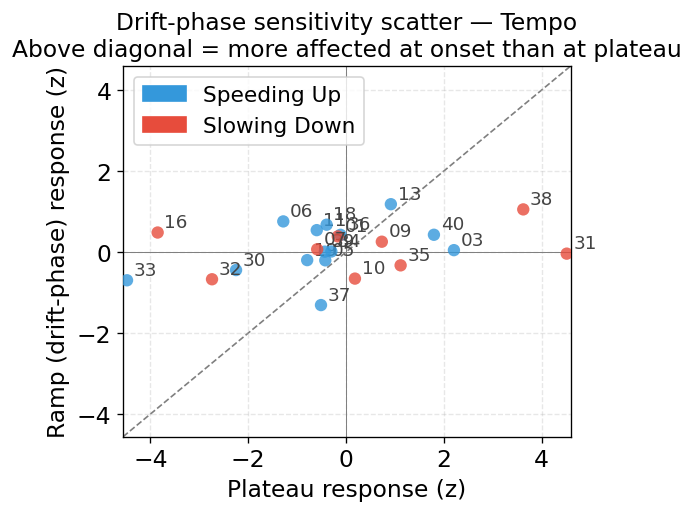

Output(outputs=({'output_type': 'display_data', 'data': {'text/plain': '<Figure size 600x540 with 1 Axes>', 'i…

In [1287]:
SPD_COL_T = "#3498db"   # blue  — speeding up  (matches trajectory plots)
SLW_COL_T = "#e74c3c"   # red   — slowing down


def _draw_tempo_bias_scatter(highlight_pid=None, df=None, ax=None):
    """
    Ramp-vs-plateau scatter for the tempo directional bias.
    Styled to match the weight notebook's _draw_bias_scatter:
      x = plateau response (z)
      y = ramp-in response (z)
    Points above the diagonal responded more at onset than at plateau.
    """
    if df is None:
        df = df_tempo_phases

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(5, 4.5))
    else:
        fig = ax.get_figure()

    DIR_MAP = {
        "speeding up":  SPD_COL_T,
        "slowing down": SLW_COL_T,
    }

    for direction, color in DIR_MAP.items():
        sub = df[
            df["direction"].str.lower().str.strip() == direction
        ].dropna(subset=["ramp_response", "plateau_response"])
        for _, row in sub.iterrows():
            is_hl  = (str(row["pid"]) == str(highlight_pid))
            ec     = "black" if is_hl else "none"
            ms     = 120    if is_hl else 55
            alpha  = 1.0    if is_hl else 0.80
            zorder = 5      if is_hl else 3
            ax.scatter(row["plateau_response"], row["ramp_response"],
                       color=color, s=ms, alpha=alpha,
                       edgecolors=ec, linewidths=1.8, zorder=zorder)
            ax.annotate(
                str(row["pid"]),
                (row["plateau_response"], row["ramp_response"]),
                fontsize=11,
                fontweight="bold" if is_hl else "normal",
                color="black" if is_hl else "#444",
                xytext=(4, 3), textcoords="offset points",
            )

    # Diagonal = equal response at ramp and plateau
    all_vals = pd.concat([
        df["plateau_response"].dropna(),
        df["ramp_response"].dropna(),
    ])
    pad = 0.08
    lo  = float(all_vals.min()) - pad
    hi  = float(all_vals.max()) + pad
    ax.plot([lo, hi], [lo, hi], "k--", lw=1.0, alpha=0.5, zorder=1)
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.axhline(0, color="gray", lw=0.6)
    ax.axvline(0, color="gray", lw=0.6)

    from matplotlib.patches import Patch
    ax.legend(
        handles=[Patch(color=SPD_COL_T, label="Speeding Up"),
                 Patch(color=SLW_COL_T, label="Slowing Down")],
        fontsize=13,
    )
    ax.set_xlabel("Plateau response (z)", fontsize=14)
    ax.set_ylabel("Ramp (drift-phase) response (z)", fontsize=14)
    ax.set_title(
        "Drift-phase sensitivity scatter — Tempo\n"
        "Above diagonal = more affected at onset than at plateau",
        fontsize=14,
    )
    ax.grid(ls="--", alpha=0.3)

    if highlight_pid:
        row = df[df["pid"].astype(str) == str(highlight_pid)]
        if not row.empty:
            r = row.iloc[0]
            ax.set_title(
                f"Highlighted: P{highlight_pid}  ({r['direction']})  "
                f"ramp={r['ramp_response']:+.3f}  "
                f"plat={r['plateau_response']:+.3f}  "
                f"bias={r['bias_index']:+.3f}",
                fontsize=14,
            )

    if standalone:
        plt.tight_layout()
        plt.show()
    return fig


# ── Wilcoxon statistics ───────────────────────────────────────────────────────
print("=== Tempo directional bias statistics ===")
for direction in ("speeding up", "slowing down"):
    sub = df_tempo_phases[
        df_tempo_phases["direction"].str.lower().str.strip() == direction
    ].dropna(subset=["ramp_response", "plateau_response"])
    n = len(sub)
    if n < 3:
        print(f"\n{direction.upper()}: insufficient data (n={n})")
        continue
    try:
        _, p = _sp_stats.wilcoxon(sub["ramp_response"], sub["plateau_response"],
                                   zero_method="zsplit")
    except ValueError:
        print(f"\n{direction.upper()}: Wilcoxon failed (all differences zero)")
        continue
    r_eff = abs(_sp_stats.norm.ppf(p / 2)) / np.sqrt(n)
    sig   = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    print(f"\n{direction.upper()}  (n={n})")
    print(f"  Ramp:    median={sub['ramp_response'].median():+.3f}  "
          f"IQR=[{sub['ramp_response'].quantile(0.25):+.3f}, "
          f"{sub['ramp_response'].quantile(0.75):+.3f}]")
    print(f"  Plateau: median={sub['plateau_response'].median():+.3f}  "
          f"IQR=[{sub['plateau_response'].quantile(0.25):+.3f}, "
          f"{sub['plateau_response'].quantile(0.75):+.3f}]")
    print(f"  Wilcoxon (ramp vs plateau): p={p:.4f} {sig}  r={r_eff:.3f}")
    n_bias = int((sub["bias_index"] > 0).sum())
    print(f"  Directional bias (index > 0): {n_bias}/{n}")

# ── Static plot ───────────────────────────────────────────────────────────────
_tempo_bias_fig = _draw_tempo_bias_scatter()

# ── Interactive highlight dropdown ───────────────────────────────────────────
_tb_out = widgets.Output()
_tb_pid_dd = widgets.Dropdown(
    options=["(none)"] + sorted(df_tempo_phases["pid"].astype(str).unique()),
    value="(none)",
    description="Highlight:",
    style={"description_width": "70px"},
    layout=widgets.Layout(width="170px"),
)

def _refresh_tb(_=None):
    import io as _io
    _tb_out.clear_output(wait=True)
    with _tb_out:
        hl = _tb_pid_dd.value if _tb_pid_dd.value != "(none)" else None
        _fig = _draw_tempo_bias_scatter(highlight_pid=hl)
        _buf = _io.BytesIO()
        _fig.savefig(_buf, dpi=150, bbox_inches="tight", format="png")
        _buf.seek(0)
        display(_fig); plt.close(_fig)
        _btn = widgets.Button(description="Export", button_style="info",
                               icon="download", layout=widgets.Layout(width="110px"))
        _lbl = widgets.Label("")
        def _save(_, buf=_buf, pid=hl):
            _lbl.value = "Saving..."
            d = DATA_DIR / "exports" / "paper_replication"
            d.mkdir(parents=True, exist_ok=True)
            buf.seek(0)
            fname = (f"tempo_bias_scatter_hl_{pid}.png" if pid
                     else "tempo_bias_scatter.png")
            (d / fname).write_bytes(buf.read())
            _lbl.value = f"OK  {fname}"
        _btn.on_click(_save)
        display(widgets.HBox([_btn, _lbl]))

_tb_pid_dd.observe(_refresh_tb, names="value")
_refresh_tb()
display(widgets.HBox([_tb_pid_dd]), _tb_out)


## Group contact & swing analysis — weight effect

Uses the `weight_change` modulator signal (last column of each `_pressure_weight.csv`,
range 0 → ±12) to compare walking biomechanics during **baseline segments**
(`|wc| ≤ 0.5`) vs **plateau segments** (`|wc| ≥ 11.4`) within each session.

**Primary metrics:**
- **Heel contact duration (ms)** — stance time per step from pressure `detect_contacts()`
- **Swing-phase peak |gy| (°/s)** — maximum gyroscope Y-axis magnitude per swing, from IMU;
  IMU is synced to the weight phase via cross-correlation of the shared heel sensor signal

**Secondary metric:** L/R asymmetry of the plateau contact-duration response

Direction subgroups: **increasing** (wc → +12) / **decreasing** (wc → −12)

**Interpretation guide**
- *Duration baseline vs plateau*: does stance time shift when the weight cue is active?
- *Swing |gy| baseline vs plateau*: does leg-swing velocity change with the weight cue?
- *Asymmetry (asym\_dur)*: `(R_plateau − R_base) − (L_plateau − L_base)` — tests whether
  one foot responds more than the other; tested against zero with Wilcoxon
- *Effect size r*: |Z| / √N — small ≥ 0.1, medium ≥ 0.3, large ≥ 0.5

In [1288]:
from scipy.signal import correlate as _sp_correlate

# ─── Weight-file parser ────────────────────────────────────────────────────────

def parse_weight_file(path):
    """
    Parse a _pressure_weight.csv and return (df_pressure, wc_array).
    The weight_change modulator is the last space-delimited token on each line.
    """
    path = Path(path)
    if not path.exists():
        return pd.DataFrame(), np.array([])
    rows_p, wc_list = [], []
    try:
        with open(path, encoding="utf-8", errors="ignore") as fh:
            for line in fh:
                line = line.strip()
                if not line:
                    continue
                clean = line.rstrip(";").rstrip()
                tokens = clean.split()
                if len(tokens) < 3:
                    continue
                try:
                    wc = float(tokens[-1])
                except ValueError:
                    continue
                unsigned_nums = re.findall(r"[\d]+\.?[\d]*", line)
                if len(unsigned_nums) < 6:
                    continue
                try:
                    ts_ms   = float(unsigned_nums[1])
                    sensors = [float(n) for n in unsigned_nums[1:] if float(n) <= 1023]
                    if len(sensors) < 4:
                        continue
                    rows_p.append({
                        "time_s": ts_ms / 1000.0,
                        "L_toe":  sensors[0], "L_heel": sensors[1],
                        "R_toe":  sensors[2], "R_heel": sensors[3],
                    })
                    wc_list.append(wc)
                except (ValueError, IndexError):
                    continue
    except OSError:
        return pd.DataFrame(), np.array([])
    if not rows_p:
        return pd.DataFrame(), np.array([])
    df = pd.DataFrame(rows_p)
    df["time_s"] -= df["time_s"].iloc[0]
    return df, np.array(wc_list)


# ─── Contact detector ──────────────────────────────────────────────────────────

def detect_contacts(signal, t_s, baseline_mask, wc):
    """
    Hysteresis-based contact detection.
    Thresholds derived from baseline window (|wc| <= 0.5) only.
    Returns (contacts_list, enter, exit_, median).
    """
    if baseline_mask.sum() < 5:
        return [], np.nan, np.nan, np.nan
    med  = float(np.median(signal[baseline_mask]))
    rng  = float(np.max(signal[baseline_mask])) - med
    if rng <= 0:
        return [], np.nan, np.nan, np.nan
    enter = med + 0.5  * rng
    exit_ = med + 0.15 * rng

    events, in_c, ts_start, i0 = [], False, None, None
    for i in range(len(signal)):
        v = signal[i]
        if not in_c and v >= enter:
            in_c, ts_start, i0 = True, t_s[i], i
        elif in_c and v <= exit_:
            in_c = False
            events.append((ts_start, t_s[i], i0, i))

    contacts = []
    _trapz = getattr(np, "trapezoid", np.trapz)
    for ts, te, j0, j1 in events:
        dur_ms = (te - ts) * 1000
        if not (50 < dur_ms < 2000):
            continue
        seg     = np.maximum(signal[j0:j1 + 1].astype(float) - med, 0)
        impulse = float(_trapz(seg, t_s[j0:j1 + 1]))
        peak    = float(np.max(signal[j0:j1 + 1]) - med)
        t_mid   = ts + (te - ts) / 2
        idx     = int(np.searchsorted(t_s, t_mid))
        wc_val  = float(wc[idx]) if 0 <= idx < len(wc) else np.nan
        contacts.append({
            "t_start": ts, "t_end": te, "t_mid": t_mid,
            "duration_ms": dur_ms, "impulse": impulse, "peak": peak, "wc": wc_val,
        })
    return contacts, enter, exit_, med


# ─── Modulator thresholds ──────────────────────────────────────────────────────

_WC_BASE_THR  = 0.5    # |wc| <= this  → baseline segment
_WC_PLAT_THR  = 11.4   # |wc| >= this  → plateau segment
_MIN_PLAT_C   = 5
_MIN_BASE_C   = 3
# P01 and P06 have severely fragmented IMU data (BLE glitch); exclude from weight analysis
_WEIGHT_EXCLUDE = {"01", "06"}


# ─── Pressure-based group stats ───────────────────────────────────────────────

def build_group_stats_weight():
    """
    Aggregate per-participant heel contact duration and impulse segmented by
    the weight_change modulator (baseline vs plateau).

    Returns DataFrame: pid, direction, order,
      L_dur_base, L_dur_plateau, R_dur_base, R_dur_plateau, asym_dur,
      L_imp_base, L_imp_plateau, R_imp_base, R_imp_plateau, asym_imp, asym_imp_norm
    """
    rows = []
    for pid in participants:
        if pid in _WEIGHT_EXCLUDE:
            continue
        path = DATA_DIR / pid / f"{pid}_pressure_weight.csv"
        if not path.exists():
            continue
        direction = get_weight_direction(pid)
        if not direction or direction.lower() == "nan":
            continue
        order, _ = get_participant_meta(pid)

        df, wc = parse_weight_file(path)
        if df.empty or len(wc) != len(df):
            continue

        t_s           = df["time_s"].to_numpy()
        baseline_mask = np.abs(wc) <= _WC_BASE_THR

        if baseline_mask.sum() < 10 or (np.abs(wc) >= _WC_PLAT_THR).sum() < 10:
            continue

        row_out = {"pid": pid, "direction": direction, "order": order}
        valid = True
        for side, col in [("L", "L_heel"), ("R", "R_heel")]:
            sig      = df[col].to_numpy()
            contacts, _, _, _ = detect_contacts(sig, t_s, baseline_mask, wc)
            plat_c = [c for c in contacts if abs(c["wc"]) >= _WC_PLAT_THR]
            base_c = [c for c in contacts if abs(c["wc"]) <= _WC_BASE_THR]
            if len(plat_c) < _MIN_PLAT_C or len(base_c) < _MIN_BASE_C:
                valid = False; break
            row_out[f"{side}_dur_base"]    = float(np.mean([c["duration_ms"] for c in base_c]))
            row_out[f"{side}_dur_plateau"] = float(np.mean([c["duration_ms"] for c in plat_c]))
            row_out[f"{side}_imp_base"]    = float(np.mean([c["impulse"]     for c in base_c]))
            row_out[f"{side}_imp_plateau"] = float(np.mean([c["impulse"]     for c in plat_c]))

        if valid:
            Rdb = row_out["R_dur_base"];   Rdp = row_out["R_dur_plateau"]
            Ldb = row_out["L_dur_base"];   Ldp = row_out["L_dur_plateau"]
            Rib = row_out["R_imp_base"];   Rip = row_out["R_imp_plateau"]
            Lib = row_out["L_imp_base"];   Lip = row_out["L_imp_plateau"]
            row_out["asym_dur"]      = (Rdp - Rdb) - (Ldp - Ldb)
            row_out["asym_imp"]      = (Rip - Rib) - (Lip - Lib)
            row_out["asym_imp_norm"] = (
                ((Rip - Rib) / Rib - (Lip - Lib) / Lib)
                if Rib > 0 and Lib > 0 else np.nan
            )
        else:
            for k in ("L_dur_base","L_dur_plateau","R_dur_base","R_dur_plateau",
                      "asym_dur","L_imp_base","L_imp_plateau","R_imp_base",
                      "R_imp_plateau","asym_imp","asym_imp_norm"):
                row_out[k] = np.nan

        rows.append(row_out)
    return pd.DataFrame(rows)


# ─── IMU sync + swing gy ──────────────────────────────────────────────────────

def _normalize_sig(x):
    std = float(x.std())
    return (x - x.mean()) / std if std > 1e-6 else np.zeros_like(x)


def sync_imu_to_weight_phase(pid):
    """
    Align the full-experiment IMU recording to the weight-condition window by
    cross-correlating the shared heel sensor signal.

    Returns (df_imu_L, df_imu_R, wc_fn) where times are zero-based relative to
    the start of the weight phase, or (None, None, None) on failure.
    """
    wf_path = DATA_DIR / pid / f"{pid}_pressure_weight.csv"
    if not wf_path.exists():
        return None, None, None

    df_p, wc = parse_weight_file(wf_path)
    if df_p.empty or len(wc) == 0:
        return None, None, None

    t_p            = df_p["time_s"].to_numpy()
    l_heel_p       = df_p["L_heel"].to_numpy().astype(float)
    weight_dur     = float(t_p[-1])

    df_imu_L = load_imu(pid, "L")
    if df_imu_L.empty or "heel" not in df_imu_L.columns:
        return None, None, None

    t_imu    = df_imu_L["time_s"].to_numpy()
    heel_imu = df_imu_L["heel"].to_numpy().astype(float)
    dt_imu   = float(np.median(np.diff(t_imu)))
    if dt_imu <= 0:
        return None, None, None

    # Resample pressure heel to IMU sample rate
    n_rs = max(2, int(weight_dur / dt_imu))
    if n_rs > len(heel_imu):
        return None, None, None   # weight phase longer than IMU recording
    t_rs       = np.linspace(0, weight_dur, n_rs)
    heel_p_rs  = np.interp(t_rs, t_p, l_heel_p)

    # Cross-correlate to find weight-phase start in IMU time
    corr      = _sp_correlate(_normalize_sig(heel_imu),
                               _normalize_sig(heel_p_rs), mode="valid")
    best_lag  = int(np.argmax(corr))
    t_start   = float(t_imu[best_lag])
    t_end     = t_start + weight_dur

    # Slice IMU L to weight window
    mask_L  = (t_imu >= t_start) & (t_imu <= t_end)
    df_L_w  = df_imu_L[mask_L].copy().reset_index(drop=True)
    df_L_w["time_s"] -= t_start

    # Slice IMU R
    df_imu_R = load_imu(pid, "R")
    df_R_w   = None
    if not df_imu_R.empty and "heel" in df_imu_R.columns:
        t_r   = df_imu_R["time_s"].to_numpy()
        mk_r  = (t_r >= t_start) & (t_r <= t_end)
        df_R_w = df_imu_R[mk_r].copy().reset_index(drop=True)
        df_R_w["time_s"] -= t_start

    def wc_fn(t_local):
        return np.interp(t_local, t_p, wc, left=0.0, right=0.0)

    return df_L_w, df_R_w, wc_fn


def _extract_swing_gy(imu_df, wc_fn):
    """
    Extract per-swing peak |gy| from a synced IMU window.
    Uses detect_steps_with_dwell on the IMU heel column.
    Returns list of dicts: {peak_gy, wc}.
    """
    if imu_df is None or imu_df.empty:
        return []
    if "heel" not in imu_df.columns or "gy" not in imu_df.columns:
        return []
    t    = imu_df["time_s"].to_numpy()
    heel = imu_df["heel"].to_numpy().astype(float)
    gy   = imu_df["gy"].to_numpy().astype(float)

    triggers, rearms = detect_steps_with_dwell(t, heel)
    if len(triggers) < 2:
        return []

    swings = []
    for i in range(len(triggers) - 1):
        t0 = t[rearms[i]] if i < len(rearms) else t[triggers[i]]
        t1 = t[triggers[i + 1]]
        mask = (t >= t0) & (t <= t1)
        if mask.sum() < 2:
            continue
        peak_gy = float(np.abs(gy[mask]).max())
        t_mid   = (t0 + t1) / 2
        wc_val  = float(wc_fn(np.array([t_mid]))[0])
        swings.append({"peak_gy": peak_gy, "wc": wc_val})
    return swings


def build_group_stats_weight_imu():
    """
    Aggregate per-participant swing-phase peak |gy| segmented by weight_change.
    Requires IMU sync via cross-correlation — participants where sync fails are
    excluded gracefully.

    Returns DataFrame: pid, direction, order,
      swing_gy_base, swing_gy_plateau, swing_gy_pct_change
    """
    rows = []
    for pid in participants:
        if pid in _WEIGHT_EXCLUDE:
            continue
        direction = get_weight_direction(pid)
        if not direction or direction.lower() == "nan":
            continue
        order, _ = get_participant_meta(pid)

        imu_L, imu_R, wc_fn = sync_imu_to_weight_phase(pid)
        if imu_L is None:
            continue

        swings = _extract_swing_gy(imu_L, wc_fn) + _extract_swing_gy(imu_R, wc_fn)
        if not swings:
            continue

        base_gy = [s["peak_gy"] for s in swings if abs(s["wc"]) <= _WC_BASE_THR]
        plat_gy = [s["peak_gy"] for s in swings if abs(s["wc"]) >= _WC_PLAT_THR]
        if len(base_gy) < 3 or len(plat_gy) < 3:
            continue

        gy_b = float(np.mean(base_gy)); gy_p = float(np.mean(plat_gy))
        rows.append({
            "pid": pid, "direction": direction, "order": order,
            "swing_gy_base":       gy_b,
            "swing_gy_plateau":    gy_p,
            "swing_gy_pct_change": (gy_p - gy_b) / gy_b * 100.0 if gy_b > 0.001 else np.nan,
        })
    return pd.DataFrame(rows)


# ─── Group plots ──────────────────────────────────────────────────────────────

def plot_weight_group_analysis(df_stats, df_imu=None):
    """
    Three figures for the weight manipulation analysis.
      Fig 1: Heel contact duration  — baseline-wc vs plateau-wc, per direction
      Fig 2: Swing-phase peak |gy|  — same segmentation (requires df_imu)
      Fig 3: L/R duration asymmetry distribution, per direction
    Returns (fig1, fig2, fig3); fig2 is None if df_imu is None or empty.
    """
    if df_stats.empty:
        print("No weight data available.")
        return None, None, None

    INC_COLOR = "#e67e22"
    DEC_COLOR = "#9b59b6"
    GROUPS    = [("increasing", INC_COLOR), ("decreasing", DEC_COLOR)]

    def _paired_panel(ax, sub, col_base, col_end, color, grp_label, xlabel0, xlabel1):
        n = len(sub)
        if n == 0:
            ax.set_title(f"{grp_label} (n=0)"); return
        ax.boxplot([sub[col_base].values, sub[col_end].values],
                   positions=[0, 1], widths=0.4, patch_artist=True,
                   medianprops=dict(color="black", lw=2),
                   boxprops=dict(facecolor=color, alpha=0.35),
                   whiskerprops=dict(color=color), capprops=dict(color=color),
                   flierprops=dict(marker="o", color=color, alpha=0.4))
        jitter = np.random.default_rng(5).uniform(-0.06, 0.06, n)
        for b, e, j in zip(sub[col_base], sub[col_end], jitter):
            ax.plot([0+j, 1+j], [b, e], color=color, alpha=0.35, lw=0.9, zorder=2)
            ax.scatter([0+j, 1+j], [b, e], color=color, s=22, zorder=3, alpha=0.7)
        if n >= 3:
            try:
                _, p_val = stats.wilcoxon(sub[col_base], sub[col_end])
                z = stats.norm.ppf(p_val / 2); r = abs(z) / np.sqrt(n)
                sig = "***" if p_val < 0.001 else ("**" if p_val < 0.01 else ("*" if p_val < 0.05 else "ns"))
                y_top = max(sub[col_base].max(), sub[col_end].max()) * 1.08
                ax.plot([0, 1], [y_top, y_top], color="black", lw=1.0)
                ax.text(0.5, y_top * 1.005, f"{sig}  p={p_val:.3f}  r={r:.2f}",
                        ha="center", va="bottom", fontsize=13)
            except Exception:
                pass
        ax.set_xticks([0, 1]); ax.set_xticklabels([xlabel0, xlabel1], fontsize=14)
        ax.set_title(f"{grp_label}  (n={n})", fontsize=16)
        ax.grid(axis="y", linestyle="--", alpha=0.3)

    # ── Figure 1: Heel contact duration ────────────────────────────────
    fig1, axes1 = plt.subplots(1, 2, figsize=(12, 5), sharey=False)
    fig1.subplots_adjust(wspace=0.35)
    for ax, (grp, color) in zip(axes1, GROUPS):
        dur_cols = ["L_dur_base","L_dur_plateau","R_dur_base","R_dur_plateau"]
        sub = df_stats[df_stats["direction"] == grp].dropna(subset=dur_cols).copy()
        sub["mean_dur_base"]    = (sub["L_dur_base"]    + sub["R_dur_base"])    / 2
        sub["mean_dur_plateau"] = (sub["L_dur_plateau"] + sub["R_dur_plateau"]) / 2
        sub = sub.dropna(subset=["mean_dur_base", "mean_dur_plateau"])
        ax.set_ylabel("Mean heel contact duration (ms)", fontsize=14)
        _paired_panel(ax, sub, "mean_dur_base", "mean_dur_plateau", color,
                      grp.title(), "Baseline wc", "Plateau wc")
    fig1.suptitle("T6 — Heel contact duration: baseline-wc vs plateau-wc",
                  fontsize=18, y=1.01)
    plt.tight_layout()

    # ── Figure 2: Swing angular velocity ───────────────────────────────
    fig2 = None
    if df_imu is not None and not df_imu.empty:
        fig2, axes2 = plt.subplots(1, 2, figsize=(12, 5), sharey=False)
        fig2.subplots_adjust(wspace=0.35)
        for ax, (grp, color) in zip(axes2, GROUPS):
            sub = df_imu[df_imu["direction"] == grp].dropna(
                subset=["swing_gy_base", "swing_gy_plateau"])
            ax.set_ylabel("Mean peak swing |gy| (°/s)", fontsize=14)
            _paired_panel(ax, sub, "swing_gy_base", "swing_gy_plateau", color,
                          grp.title(), "Baseline wc", "Plateau wc")
        fig2.suptitle("T6 — Swing angular velocity: baseline-wc vs plateau-wc",
                      fontsize=18, y=1.01)
        plt.tight_layout()

    # ── Figure 3: L/R asymmetry ─────────────────────────────────────────
    fig3, ax3 = plt.subplots(figsize=(8, 4))
    for i, (grp, color) in enumerate(GROUPS):
        sub = df_stats[df_stats["direction"] == grp]["asym_dur"].dropna()
        if len(sub) == 0: continue
        ax3.boxplot(sub.values, positions=[i], widths=0.4, vert=False,
                    patch_artist=True,
                    medianprops=dict(color="black", lw=2),
                    boxprops=dict(facecolor=color, alpha=0.40),
                    whiskerprops=dict(color=color), capprops=dict(color=color),
                    flierprops=dict(marker="o", color=color, alpha=0.4))
        jitter = np.random.default_rng(6).uniform(-0.12, 0.12, len(sub))
        ax3.scatter(sub.values, [i]*len(sub)+jitter, color=color, s=25, alpha=0.65, zorder=3)
        ax3.text(float(sub.median()), i + 0.28,
                 f"med={sub.median():.1f}ms  n={len(sub)}",
                 ha="center", fontsize=13, color=color)
    ax3.axvline(0, color="black", lw=1.2, linestyle="--", label="No asymmetry")
    ax3.set_yticks([0, 1])
    ax3.set_yticklabels([g.title() for g, _ in GROUPS], fontsize=14)
    ax3.set_xlabel("Duration asymmetry (R−L) plateau shift (ms)", fontsize=14)
    ax3.set_title("T6 — L/R heel-contact-duration asymmetry of weight response", fontsize=18)
    ax3.legend(fontsize=13); ax3.grid(axis="x", linestyle="--", alpha=0.3)
    plt.tight_layout()

    return fig1, fig2, fig3


# ─── Per-plot display helper ──────────────────────────────────────────────────

def _show_weight_fig_with_export(fig, fname, subdir="group_analysis_weight"):
    """Display figure in Output widget with an individual export button below."""
    import io
    if fig is None:
        return
    buf = io.BytesIO()
    fig.savefig(buf, dpi=150, bbox_inches="tight", format="png")
    buf.seek(0)
    out_img = widgets.Output()
    with out_img:
        display(fig)
    plt.close(fig)
    btn = widgets.Button(description="Export", button_style="info", icon="download",
                         layout=widgets.Layout(width="110px"))
    lbl = widgets.Label("")
    def _do_save(_):
        lbl.value = "Saving…"
        d = _export_dir(subdir)
        buf.seek(0)
        (d / f"{fname}.png").write_bytes(buf.read())
        lbl.value = f"✓  {fname}.png"
    btn.on_click(_do_save)
    display(widgets.VBox([out_img, widgets.HBox([btn, lbl])]))


In [1289]:
df_weight     = build_group_stats_weight()
print("Building IMU swing stats (cross-correlation sync)…")
df_weight_imu = build_group_stats_weight_imu()
print(f"  IMU sync succeeded for {len(df_weight_imu)} participants")

print("\n=== Weight group summary ===")
for grp in ("increasing", "decreasing"):
    print(f"\n{grp.upper()}")

    # Duration
    sub_dur = df_weight[df_weight["direction"] == grp].copy()
    sub_dur["mean_dur_base"]    = (sub_dur["L_dur_base"]    + sub_dur["R_dur_base"])    / 2
    sub_dur["mean_dur_plateau"] = (sub_dur["L_dur_plateau"] + sub_dur["R_dur_plateau"]) / 2
    sub_dur = sub_dur.dropna(subset=["mean_dur_base", "mean_dur_plateau"])
    if len(sub_dur) >= 3:
        _, p = stats.wilcoxon(sub_dur["mean_dur_base"], sub_dur["mean_dur_plateau"])
        z = stats.norm.ppf(p / 2); r = abs(z) / np.sqrt(len(sub_dur))
        print(f"  Contact duration (n={len(sub_dur)})")
        print(f"    Baseline wc: median={sub_dur['mean_dur_base'].median():.1f}ms  "
              f"IQR=[{sub_dur['mean_dur_base'].quantile(0.25):.1f}, "
              f"{sub_dur['mean_dur_base'].quantile(0.75):.1f}]")
        print(f"    Plateau wc:  median={sub_dur['mean_dur_plateau'].median():.1f}ms  "
              f"IQR=[{sub_dur['mean_dur_plateau'].quantile(0.25):.1f}, "
              f"{sub_dur['mean_dur_plateau'].quantile(0.75):.1f}]")
        print(f"    Wilcoxon:    p={p:.4f}  r={r:.3f}")
    else:
        print(f"  Duration: insufficient data (n={len(sub_dur)})")

    # Swing gy
    sub_gy = df_weight_imu[df_weight_imu["direction"] == grp].dropna(
        subset=["swing_gy_base", "swing_gy_plateau"])
    if len(sub_gy) >= 3:
        _, p = stats.wilcoxon(sub_gy["swing_gy_base"], sub_gy["swing_gy_plateau"])
        z = stats.norm.ppf(p / 2); r = abs(z) / np.sqrt(len(sub_gy))
        print(f"  Swing |gy| (n={len(sub_gy)})")
        print(f"    Baseline wc: median={sub_gy['swing_gy_base'].median():.2f}  "
              f"IQR=[{sub_gy['swing_gy_base'].quantile(0.25):.2f}, "
              f"{sub_gy['swing_gy_base'].quantile(0.75):.2f}]")
        print(f"    Plateau wc:  median={sub_gy['swing_gy_plateau'].median():.2f}  "
              f"IQR=[{sub_gy['swing_gy_plateau'].quantile(0.25):.2f}, "
              f"{sub_gy['swing_gy_plateau'].quantile(0.75):.2f}]")
        print(f"    Wilcoxon:    p={p:.4f}  r={r:.3f}")
    else:
        print(f"  Swing |gy|: insufficient data (n={len(sub_gy)})")

    # Asymmetry
    sub_asy = df_weight[df_weight["direction"] == grp].dropna(subset=["asym_dur"])
    if len(sub_asy) >= 3:
        _, p_a = stats.wilcoxon(sub_asy["asym_dur"], zero_method="zsplit")
        z_a = stats.norm.ppf(p_a / 2); r_a = abs(z_a) / np.sqrt(len(sub_asy))
        print(f"  Duration asymmetry (n={len(sub_asy)})")
        print(f"    Median={sub_asy['asym_dur'].median():.2f}ms  "
              f"IQR=[{sub_asy['asym_dur'].quantile(0.25):.2f}, "
              f"{sub_asy['asym_dur'].quantile(0.75):.2f}]")
        print(f"    Wilcoxon vs 0: p={p_a:.4f}  r={r_a:.3f}")

# ── Display each figure with its own export button ──────────────────────────
_WEIGHT_FNAMES = [
    "fig1_weight_duration",
    "fig2_weight_swing_gy",
    "fig3_weight_asymmetry",
]
_weight_figs = plot_weight_group_analysis(df_weight, df_weight_imu)
if _weight_figs:
    for _fig, _fname in zip(_weight_figs, _WEIGHT_FNAMES):
        _show_weight_fig_with_export(_fig, _fname)


Building IMU swing stats (cross-correlation sync)…
  IMU sync succeeded for 20 participants

=== Weight group summary ===

INCREASING
  Contact duration (n=8)
    Baseline wc: median=524.7ms  IQR=[507.3, 565.7]
    Plateau wc:  median=526.6ms  IQR=[500.1, 544.5]
    Wilcoxon:    p=0.9453  r=0.024
  Swing |gy| (n=8)
    Baseline wc: median=22.63  IQR=[18.04, 61.17]
    Plateau wc:  median=22.00  IQR=[17.82, 52.15]
    Wilcoxon:    p=0.0547  r=0.679
  Duration asymmetry (n=8)
    Median=16.93ms  IQR=[3.74, 38.24]
    Wilcoxon vs 0: p=0.0547  r=0.679

DECREASING
  Contact duration (n=12)
    Baseline wc: median=528.4ms  IQR=[507.8, 571.6]
    Plateau wc:  median=544.9ms  IQR=[484.0, 571.4]
    Wilcoxon:    p=0.2334  r=0.344
  Swing |gy| (n=12)
    Baseline wc: median=22.21  IQR=[20.66, 24.32]
    Plateau wc:  median=22.79  IQR=[21.79, 26.28]
    Wilcoxon:    p=0.3394  r=0.276
  Duration asymmetry (n=12)
    Median=0.11ms  IQR=[-14.61, 24.71]
    Wilcoxon vs 0: p=0.7334  r=0.098


In [1290]:
_WEIGHT_FNAMES = [
    "fig1_weight_duration",
    "fig2_weight_swing_gy",
    "fig3_weight_asymmetry",
]

wgt_export_all_btn    = widgets.Button(
    description="Export all plots",
    button_style="warning",
    icon="download",
    layout=widgets.Layout(width="160px"),
)
wgt_export_all_status = widgets.Label("")

def do_wgt_export_all(_):
    wgt_export_all_status.value = "Exporting all figures…"
    figs = plot_weight_group_analysis(df_weight, df_weight_imu)
    if not figs:
        wgt_export_all_status.value = "No data to export."
        return
    d = _export_dir("group_analysis_weight")
    for fig, fname in zip(figs, _WEIGHT_FNAMES):
        if fig is not None:
            _save_fig(fig, d / f"{fname}.png")
            plt.close(fig)
    wgt_export_all_status.value = "✓ All figures saved to exports/group_analysis_weight/"

wgt_export_all_btn.on_click(do_wgt_export_all)
display(widgets.HBox([wgt_export_all_btn, wgt_export_all_status]))


## Per-participant weight explorer

Pick a participant to see the raw heel pressure signals with detected contacts
shaded by modulator level (gray = baseline, green = plateau), and scatter plots
of contact duration and impulse vs `weight_change` value.

Cluster mean lines show the average in the baseline (`|wc| ≤ 0.5`, gray segment)
and plateau (`|wc| ≥ 11.4`, green segment) windows. The boxed annotation reports
the Δ = plateau − baseline shift for each metric.

In [1291]:
_wgt_participants = sorted([
    p for p in participants
    if p not in _WEIGHT_EXCLUDE
    and (DATA_DIR / p / f"{p}_pressure_weight.csv").exists()
    and get_weight_direction(p) not in ("", "nan")
])

def _cluster_means(items, value_key, plateau_thr):
    base = [d[value_key] for d in items if abs(d["wc"]) <= _WC_BASE_THR]
    plat = [d[value_key] for d in items if abs(d["wc"]) >= plateau_thr]
    if len(base) < 3 or len(plat) < 3:
        return None, None, None
    bm = float(np.mean(base)); pm = float(np.mean(plat))
    return bm, pm, pm - bm

def _draw_cluster_lines(ax, x_lo, x_hi, plateau_thr,
                         base_mean, plateau_mean, color_b="#888", color_p="#2a7"):
    if base_mean is not None:
        ax.hlines(base_mean, x_lo, _WC_BASE_THR, colors=color_b, lw=2.5,
                  label=f"baseline mean = {base_mean:.1f}")
    if plateau_mean is not None:
        ax.hlines(plateau_mean, plateau_thr, x_hi, colors=color_p, lw=2.5,
                  label=f"plateau mean = {plateau_mean:.1f}")

def plot_weight_session(pid):
    path = DATA_DIR / pid / f"{pid}_pressure_weight.csv"
    df, wc = parse_weight_file(path)
    if df.empty:
        print(f"No data for {pid}"); return

    t_s           = df["time_s"].to_numpy()
    baseline_mask = np.abs(wc) <= _WC_BASE_THR
    peak_wc       = float(np.max(np.abs(wc)))
    if peak_wc < 1:
        print(f"P{pid}: modulator flat — skipping"); return
    plateau_thr = 0.95 * peak_wc
    x_pad       = 1.0
    x_lo, x_hi  = -(peak_wc + x_pad), peak_wc + x_pad

    # Pressure contacts
    L_c, _, _, _ = detect_contacts(df["L_heel"].to_numpy(), t_s, baseline_mask, wc)
    R_c, _, _, _ = detect_contacts(df["R_heel"].to_numpy(), t_s, baseline_mask, wc)

    # L-R pair differences
    R_times = np.array([c["t_mid"] for c in R_c])
    pairs = []
    for cl in L_c:
        if len(R_times) == 0: continue
        j = int(np.argmin(np.abs(R_times - cl["t_mid"])))
        cr = R_c[j]
        if abs(cr["t_mid"] - cl["t_mid"]) < 1.0:
            pairs.append({"wc": (cl["wc"] + cr["wc"])/2,
                          "dur_diff": cr["duration_ms"] - cl["duration_ms"],
                          "imp_diff": cr["impulse"] - cl["impulse"]})

    # IMU sync for swing gy
    imu_L, imu_R, wc_fn = sync_imu_to_weight_phase(pid)
    swings_L = _extract_swing_gy(imu_L, wc_fn) if imu_L is not None else []
    swings_R = _extract_swing_gy(imu_R, wc_fn) if imu_R is not None else []
    has_imu  = len(swings_L) > 0 or len(swings_R) > 0

    n_rows   = 3 if has_imu else 2
    clrs_p   = ["#2a7" if abs(d["wc"]) >= plateau_thr
                else ("#888" if abs(d["wc"]) <= _WC_BASE_THR else "#ccc")
                for d in pairs]

    direction = get_weight_direction(pid)
    fig, axes = plt.subplots(n_rows, 2, figsize=(13, 4.5 * n_rows))

    # Row 0: duration and impulse per contact (L & R)
    for col_idx, (metric, ylabel) in enumerate([
            ("duration_ms", "contact duration (ms)"),
            ("impulse",     "contact impulse")]):
        ax = axes[0, col_idx]
        ax.scatter([c["wc"] for c in L_c], [c[metric] for c in L_c],
                   color="#1f77b4", s=18, alpha=0.5, label="L", edgecolor="none")
        ax.scatter([c["wc"] for c in R_c], [c[metric] for c in R_c],
                   color="#d62728", s=18, alpha=0.5, label="R", edgecolor="none")
        Lb, Lp, _ = _cluster_means(L_c, metric, plateau_thr)
        Rb, Rp, _ = _cluster_means(R_c, metric, plateau_thr)
        _draw_cluster_lines(ax, x_lo, x_hi, plateau_thr, Lb, Lp, "#1f77b4", "#1f77b4")
        _draw_cluster_lines(ax, x_lo, x_hi, plateau_thr, Rb, Rp, "#d62728", "#d62728")
        ax.set_xlabel("weight_change at contact"); ax.set_ylabel(ylabel)
        ax.set_title(f"{ylabel.split('(')[0].strip()} per contact (L & R)")
        ax.set_xlim(x_lo, x_hi); ax.legend(fontsize=11); ax.grid(alpha=0.3)

    # Row 1: R-L differences per pair
    P = pd.DataFrame(pairs)
    for col_idx, (diff_key, ylabel) in enumerate([
            ("dur_diff", "R − L duration (ms)"),
            ("imp_diff", "R − L impulse")]):
        ax = axes[1, col_idx]
        if len(P) > 0:
            ax.scatter(P["wc"], P[diff_key], c=clrs_p, s=30, alpha=0.85,
                       edgecolor="k", linewidths=0.4)
        ax.axhline(0, color="gray", lw=0.7)
        bm, pm, delta = _cluster_means(pairs, diff_key, plateau_thr)
        _draw_cluster_lines(ax, x_lo, x_hi, plateau_thr, bm, pm)
        if delta is not None:
            ax.annotate(f"Δ = {delta:+.2f}",
                        xy=(0.5, 0.97), xycoords="axes fraction",
                        ha="center", va="top", fontsize=16,
                        bbox=dict(facecolor="white", edgecolor="#666", alpha=0.9, pad=4))
        ax.set_xlabel("weight_change at pair midpoint"); ax.set_ylabel(ylabel)
        ax.set_title(f"R−L {diff_key.split('_')[0]} per pair (n={len(P)})")
        ax.set_xlim(x_lo, x_hi); ax.legend(fontsize=11); ax.grid(alpha=0.3)

    # Row 2: swing |gy| per foot vs wc (if IMU available)
    if has_imu:
        for col_idx, (swings, foot, color) in enumerate([
                (swings_L, "L", "#1f77b4"),
                (swings_R, "R", "#d62728")]):
            ax = axes[2, col_idx]
            if swings:
                ax.scatter([s["wc"] for s in swings], [s["peak_gy"] for s in swings],
                           color=color, s=20, alpha=0.6, edgecolor="none")
                sb, sp, delta = _cluster_means(swings, "peak_gy", plateau_thr)
                _draw_cluster_lines(ax, x_lo, x_hi, plateau_thr, sb, sp, color, color)
                if delta is not None:
                    ax.annotate(f"Δ = {delta:+.2f} °/s",
                                xy=(0.5, 0.97), xycoords="axes fraction",
                                ha="center", va="top", fontsize=16,
                                bbox=dict(facecolor="white", edgecolor="#666", alpha=0.9, pad=4))
            else:
                ax.text(0.5, 0.5, "IMU sync failed", ha="center", va="center",
                        transform=ax.transAxes, color="gray")
            ax.set_xlabel("weight_change at swing midpoint")
            ax.set_ylabel("peak |gy| per swing (°/s)")
            ax.set_title(f"{foot} foot swing angular velocity vs wc")
            ax.set_xlim(x_lo, x_hi); ax.legend(fontsize=11); ax.grid(alpha=0.3)

    fig.suptitle(
        f"T6 — P{pid}  ({direction})  —  contact metrics & swing gy vs weight_change",
        fontsize=18)
    fig.tight_layout(); plt.show()


# ── widget ──────────────────────────────────────────────────────────────────
_wgt_pid_dd = widgets.Dropdown(
    options=_wgt_participants,
    value=_wgt_participants[0] if _wgt_participants else None,
    description="Participant:",
    style={"description_width": "90px"},
    layout=widgets.Layout(width="200px"),
)
_wgt_out = widgets.Output()

def _refresh_wgt(_=None):
    _wgt_out.clear_output(wait=True)
    with _wgt_out:
        plot_weight_session(_wgt_pid_dd.value)

_wgt_pid_dd.observe(_refresh_wgt, names="value")
_refresh_wgt()
display(widgets.HBox([_wgt_pid_dd]), _wgt_out)


Output()